Machine Learning Assignment 1  
Problem Statement 4 – Symptom-Based Prediction  
Group 128  
Group Members & Contribution

- 2025AG05624 – 100%  
- Member 2 Name (ID: XXXXX) – 100%  
- Member 3 Name (ID: XXXXX) – 100%  
- Member 4 Name (ID: XXXXX) – 100%  

Imports

In [22]:
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import seaborn as sns


# Q1. Data Understanding & Audit  
a. Load the dataset and perform a schema validation check:  
   • Data types  
   • Unique value distributions  
   • Class balance  
b. Identify:  
   • Whether features are ordinal, nominal, or binary  
   • Any inconsistencies in encoding  
c. Write a short note:  
Why is this dataset not suitable for naive linear assumptions?  

In [3]:
# a. Load the dataset and perform a schema validation check:
import pandas as pd

df = pd.read_excel("PS4.xlsx")
print(df.shape)
df.info() # Data types
df.nunique() #Unique value distributions
df['class'].value_counts() # Class balance

(520, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class           

,count
class,
Positive,320
Negative,200


### Observations:

- The dataset contains 520 patient records and 17 features
- All columns have 520 non-null values hence indicating no missing data
- Age is the only numerical feature(int), while all other features string
- The target variable 'class' has 320 Positive and 200 Negative cases, hence it is a slightly imbalanced dataset

In [10]:
df.nunique()
for col in df.columns:
    print(col, ":", df[col].unique())

Age : [40 58 41 45 60 55 57 66 67 70 44 38 35 61 54 43 62 39 48 32 42 52 53 37
 49 63 30 50 46 36 51 59 65 25 47 28 68 56 31 85 90 72 69 79 34 16 33 64
 27 29 26]
Gender : ['Male' 'Female']
Polyuria : ['No' 'Yes']
Polydipsia : ['Yes' 'No']
sudden weight loss : ['No' 'Yes']
weakness : ['Yes' 'No']
Polyphagia : ['No' 'Yes']
Genital thrush : ['No' 'Yes']
visual blurring : ['No' 'Yes']
Itching : ['Yes' 'No']
Irritability : ['No' 'Yes']
delayed healing : ['Yes' 'No']
partial paresis : ['No' 'Yes']
muscle stiffness : ['Yes' 'No']
Alopecia : ['Yes' 'No']
Obesity : ['Yes' 'No']
class : ['Positive' 'Negative']


# b. Feature Type Identification  
Features are categorized as follows :  
- Binary Features : Most symptom columns contain Yes/No values (Eg. Polyuria, Polydipsia, weakness)  
- Nominal Features : Gender (Male/Female)  
- Numerical Feature : Age  

Encoding Issues :  
- Binary features are stored as 'Yes'/'No' instead of 1/0  
- This may cause issues in machine learning models  
- Conversion to numerical format will be required

# c. Why this dataset is not suitable for naive linear assumptions?  
This dataset is not suitable for naive linear assumptions due to the following reasons:  
1. Binary Features:  
   Most features are binary, which does not provide continuous variation required for linear models.    

2. Lack of Gradients:  
   Linear models rely on gradients for optimization, but binary inputs provide limited gradient information.        

3. Non-linear Relationships:  
   The relationship between symptoms and disease outcome is likely conditional and non-linear, as combinations of symptoms may influence the prediction differently than individual symptoms.

#**EDA**


This is an Health domain binary classification problem where Core Problem

Type: Binary Classification
The dataset represents patients evaluated for a metabolic disorder
Output (target variable) is implicitly:
0 → No disorder = negitive
1 → Disorder present = positive

all assumtions and considerations under eda will be taken with respect to domain knowldege .

Describe helps to understad the data's 5 point summary especially numerical values .

In [11]:
data = df

In [12]:
data.describe(include='all')

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
count,520.000000,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520
unique,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,NaN,Male,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,Positive
freq,NaN,328,262,287,303,305,283,404,287,267,394,281,296,325,341,432,320
mean,48.028846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,12.151466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,47.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


no complete uique columns like id,rownumber etc which would be compltely irrelavent.

In [13]:
target_var=data['class']
target_var

,class
0,Positive
1,Positive
2,Positive
3,Positive
4,Positive
...,...
515,Positive
516,Positive
517,Positive
518,Negative


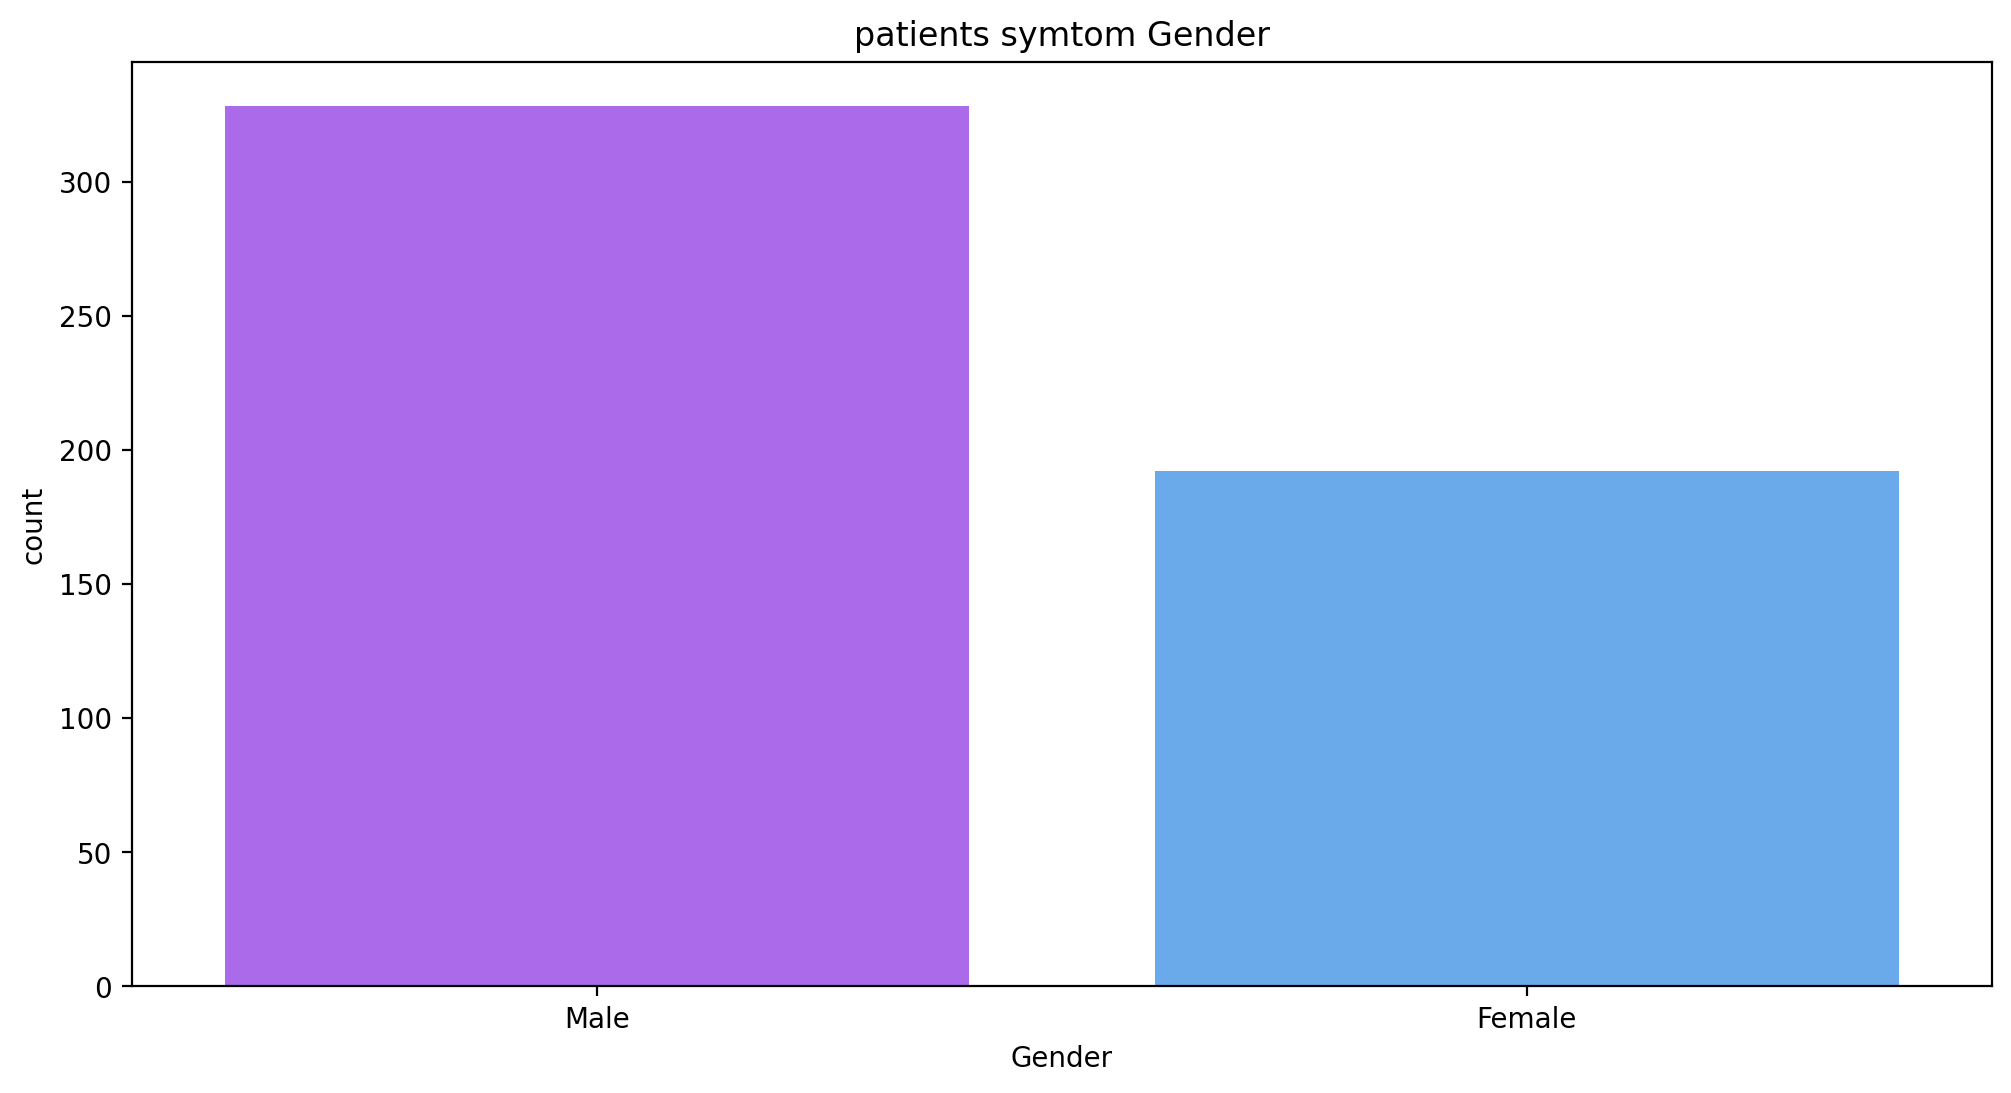

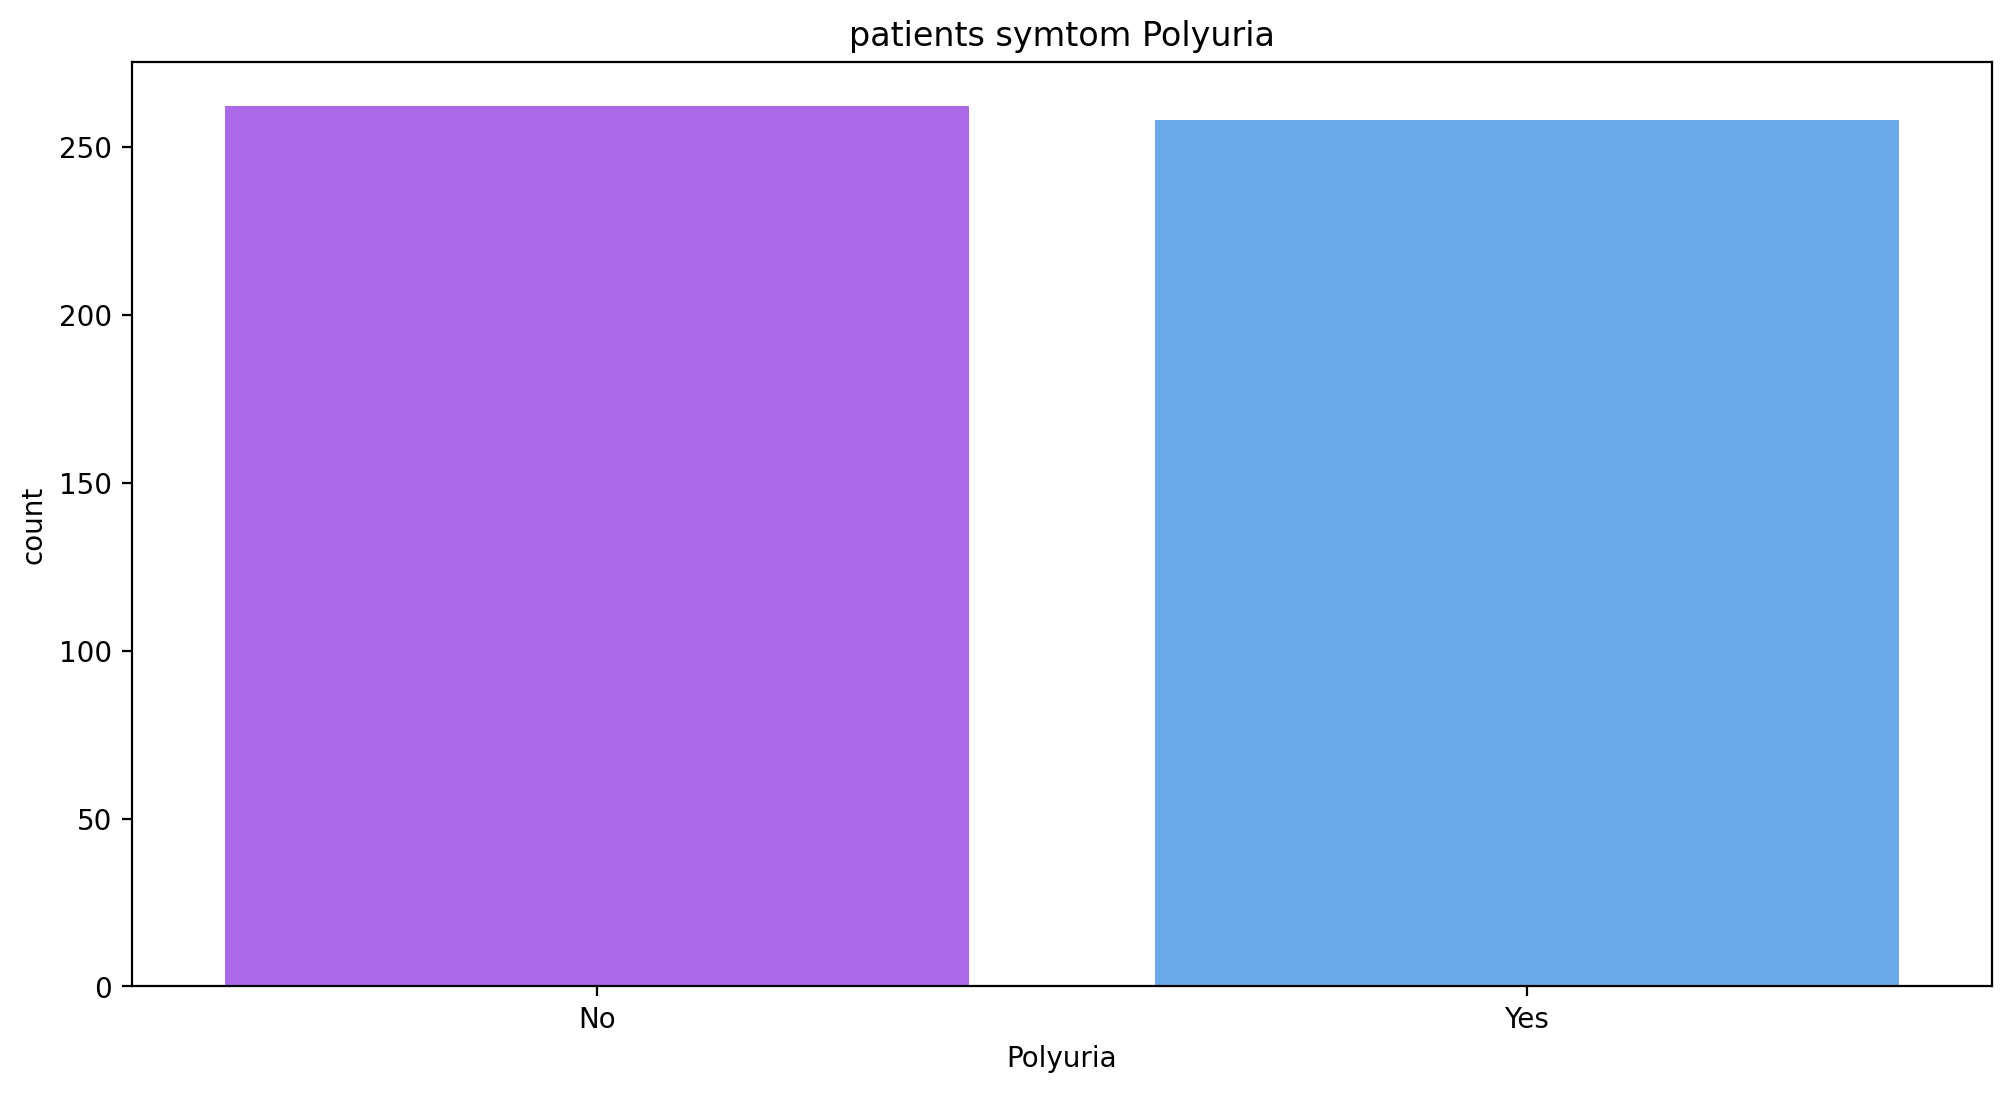

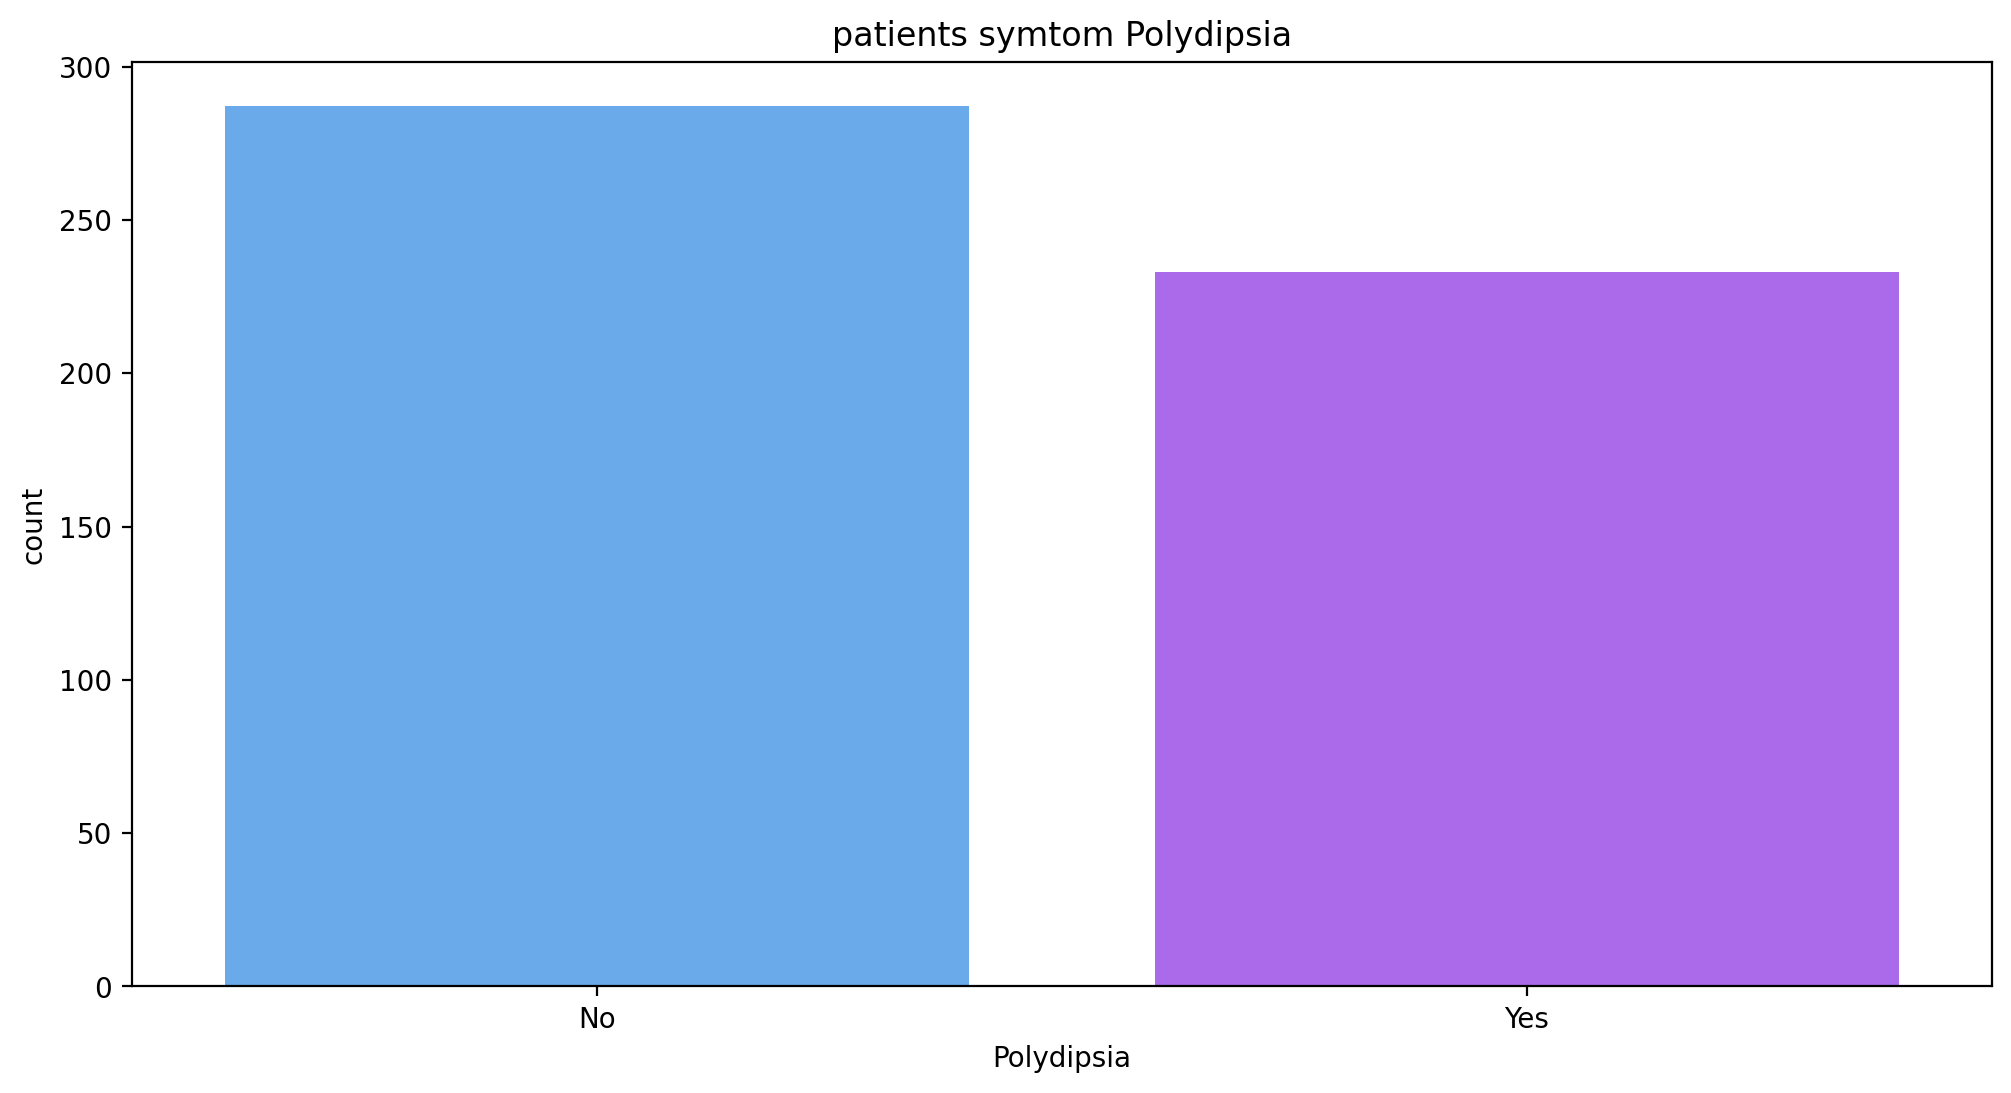

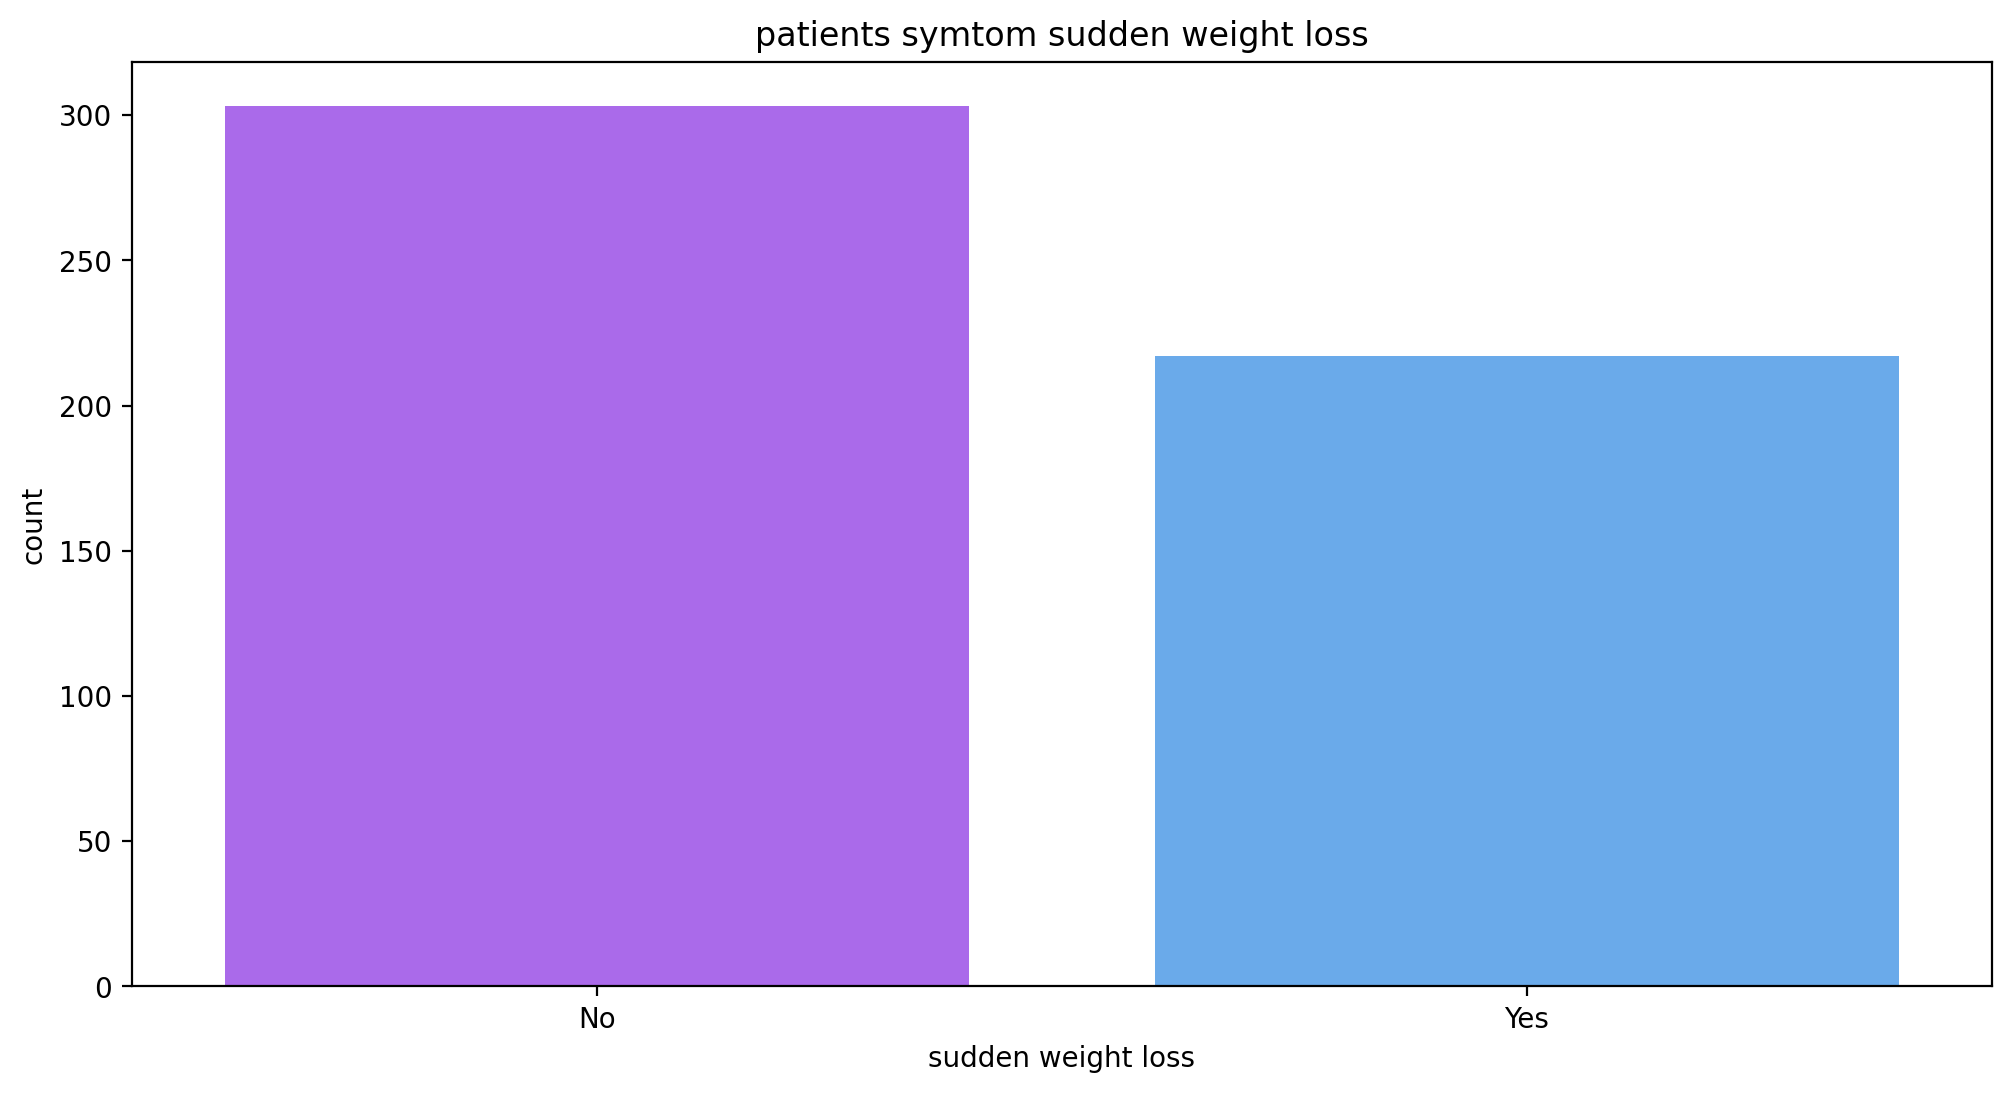

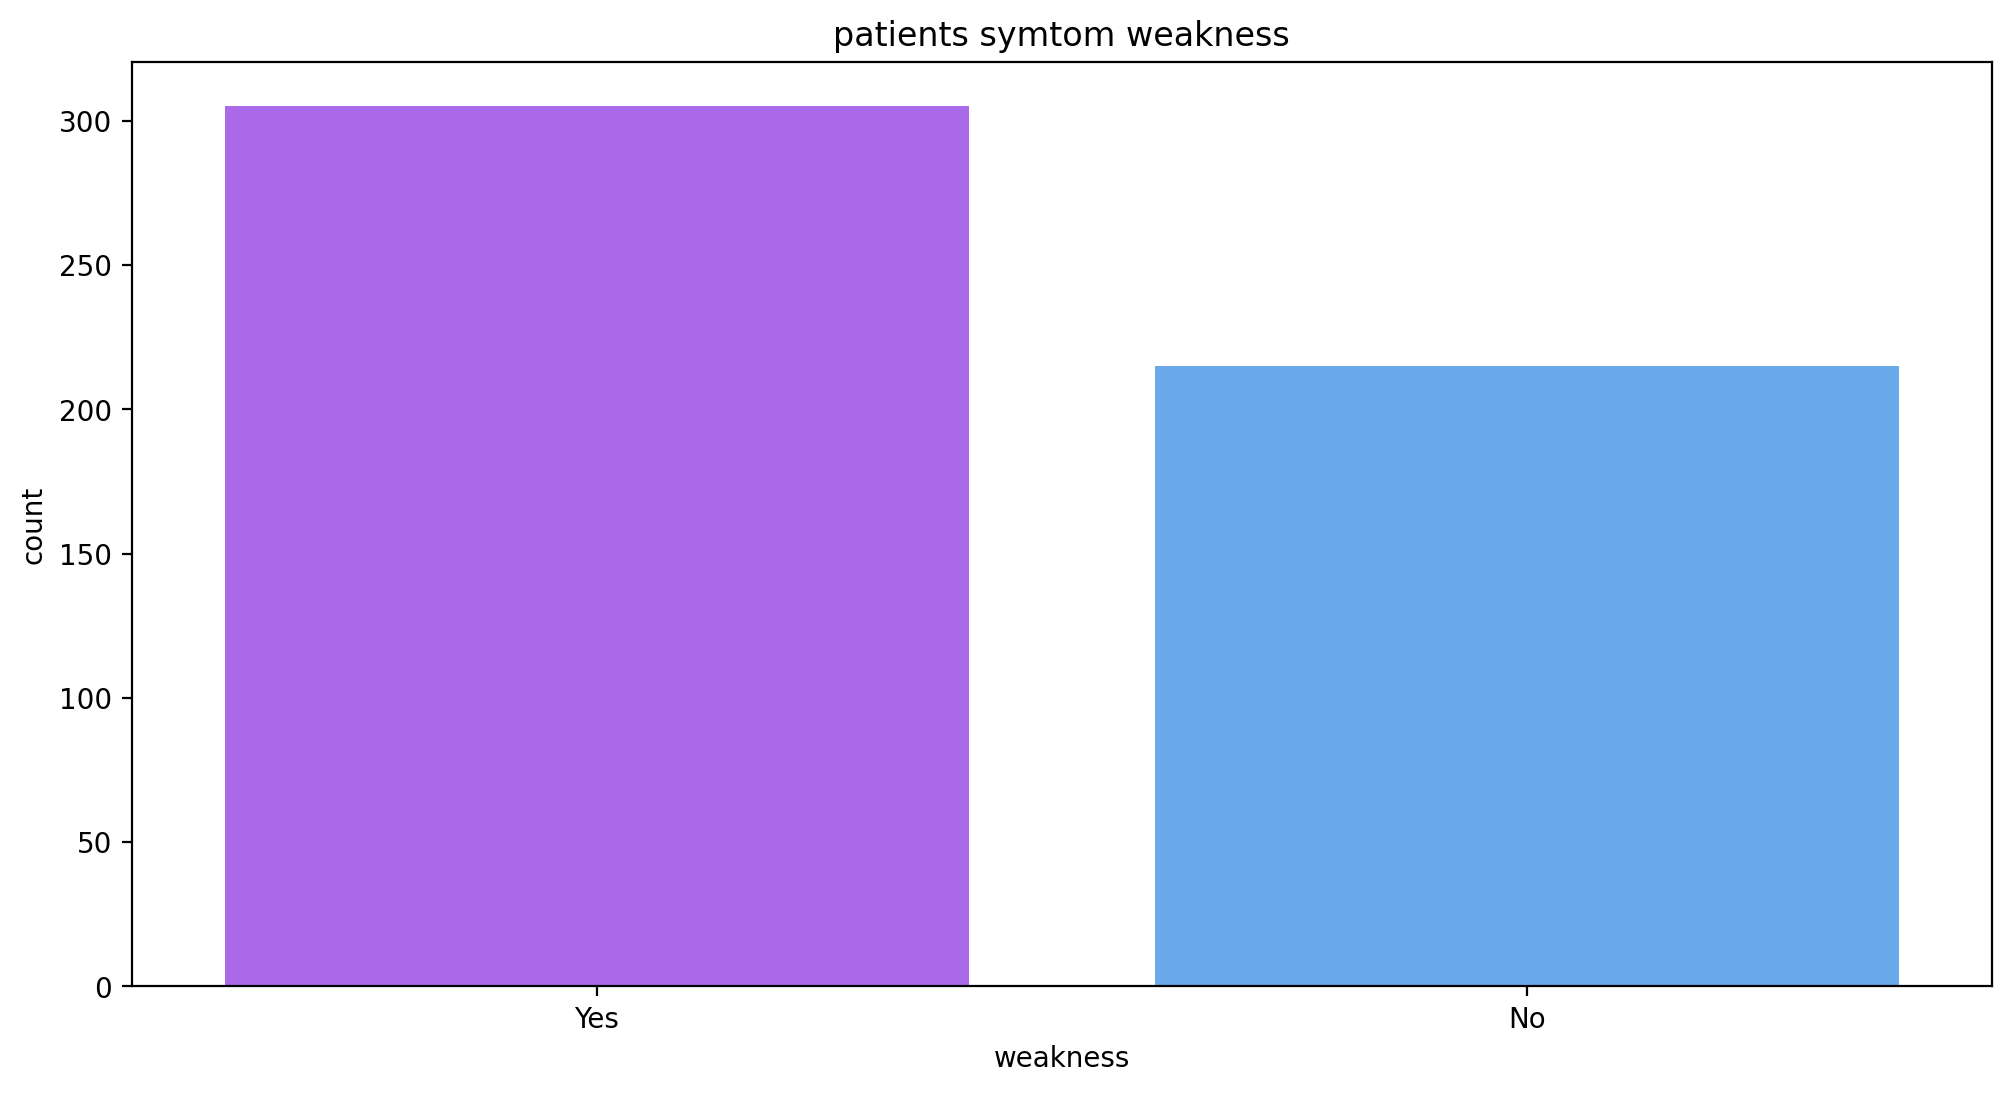

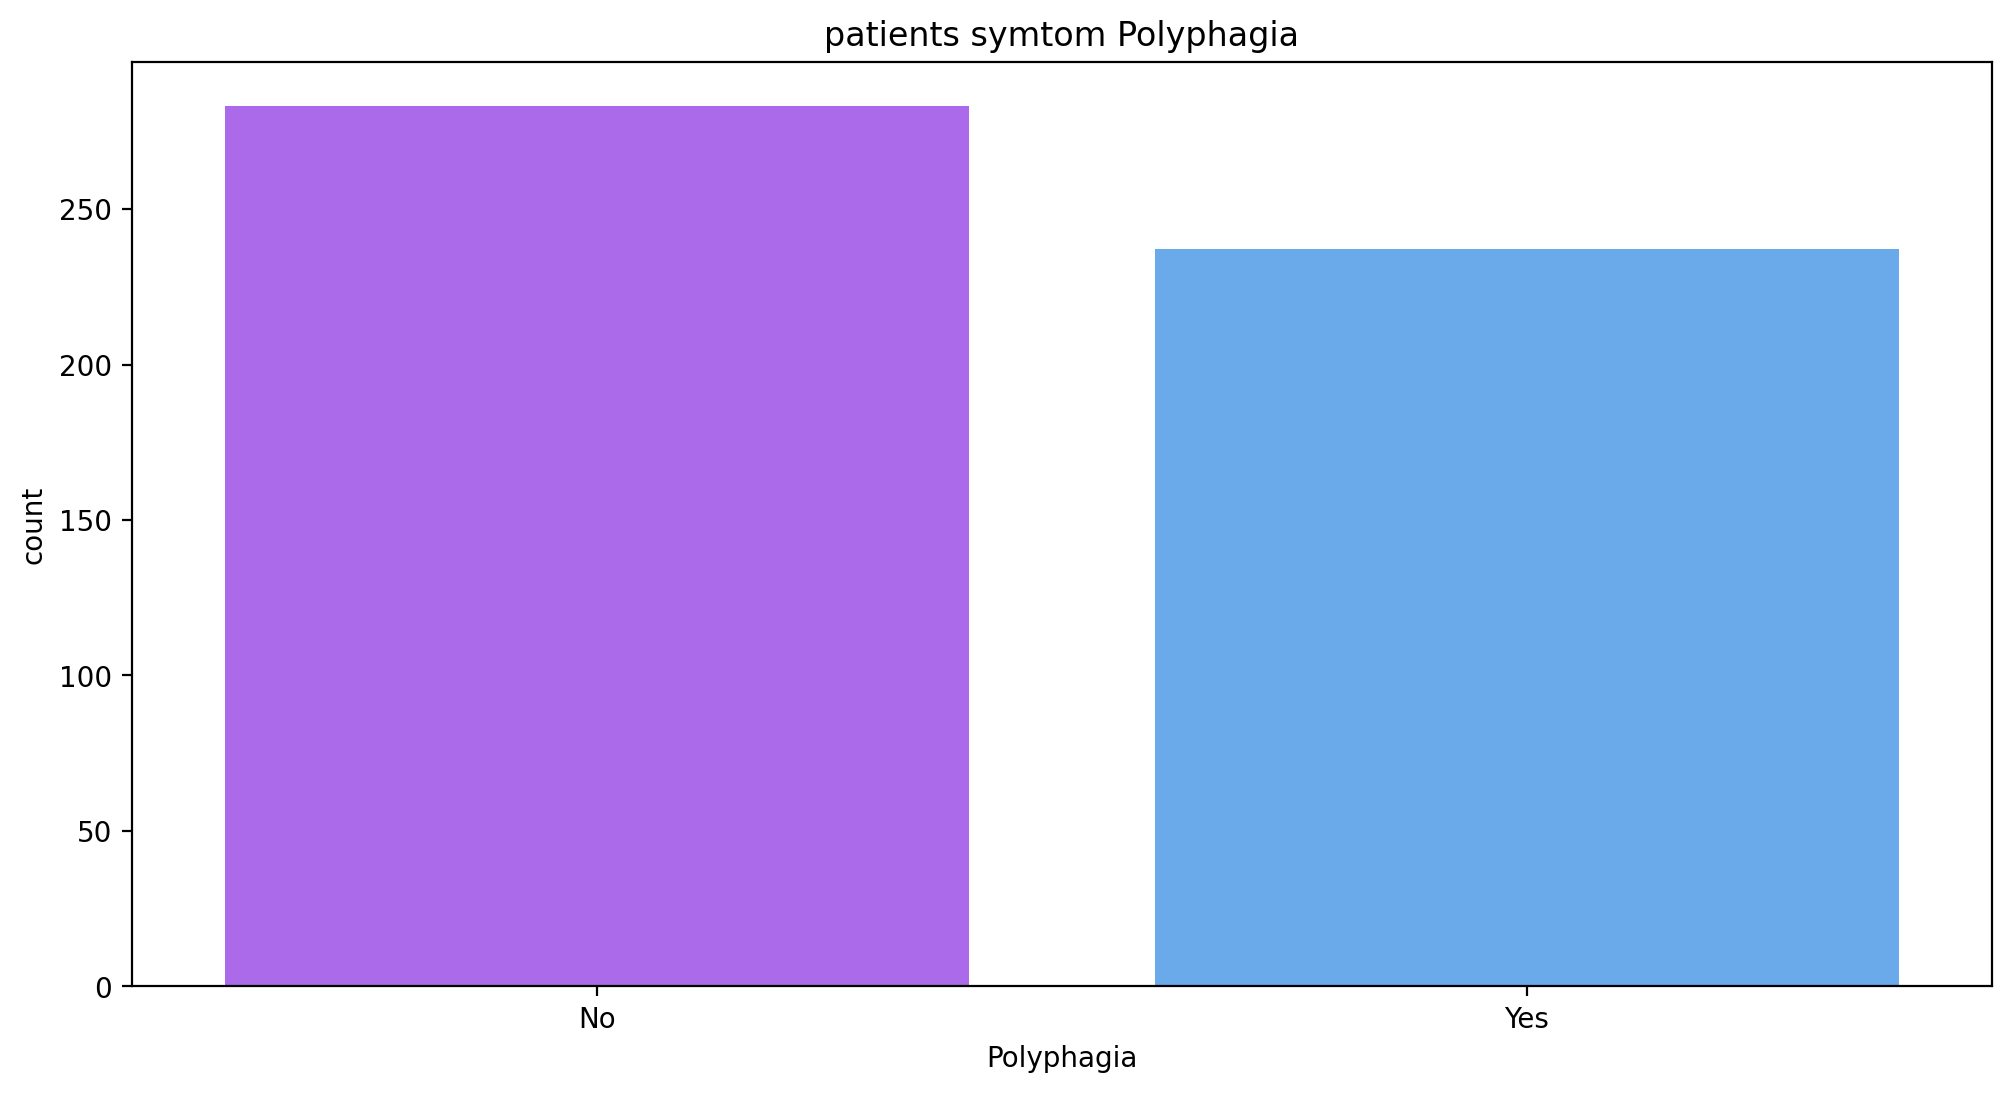

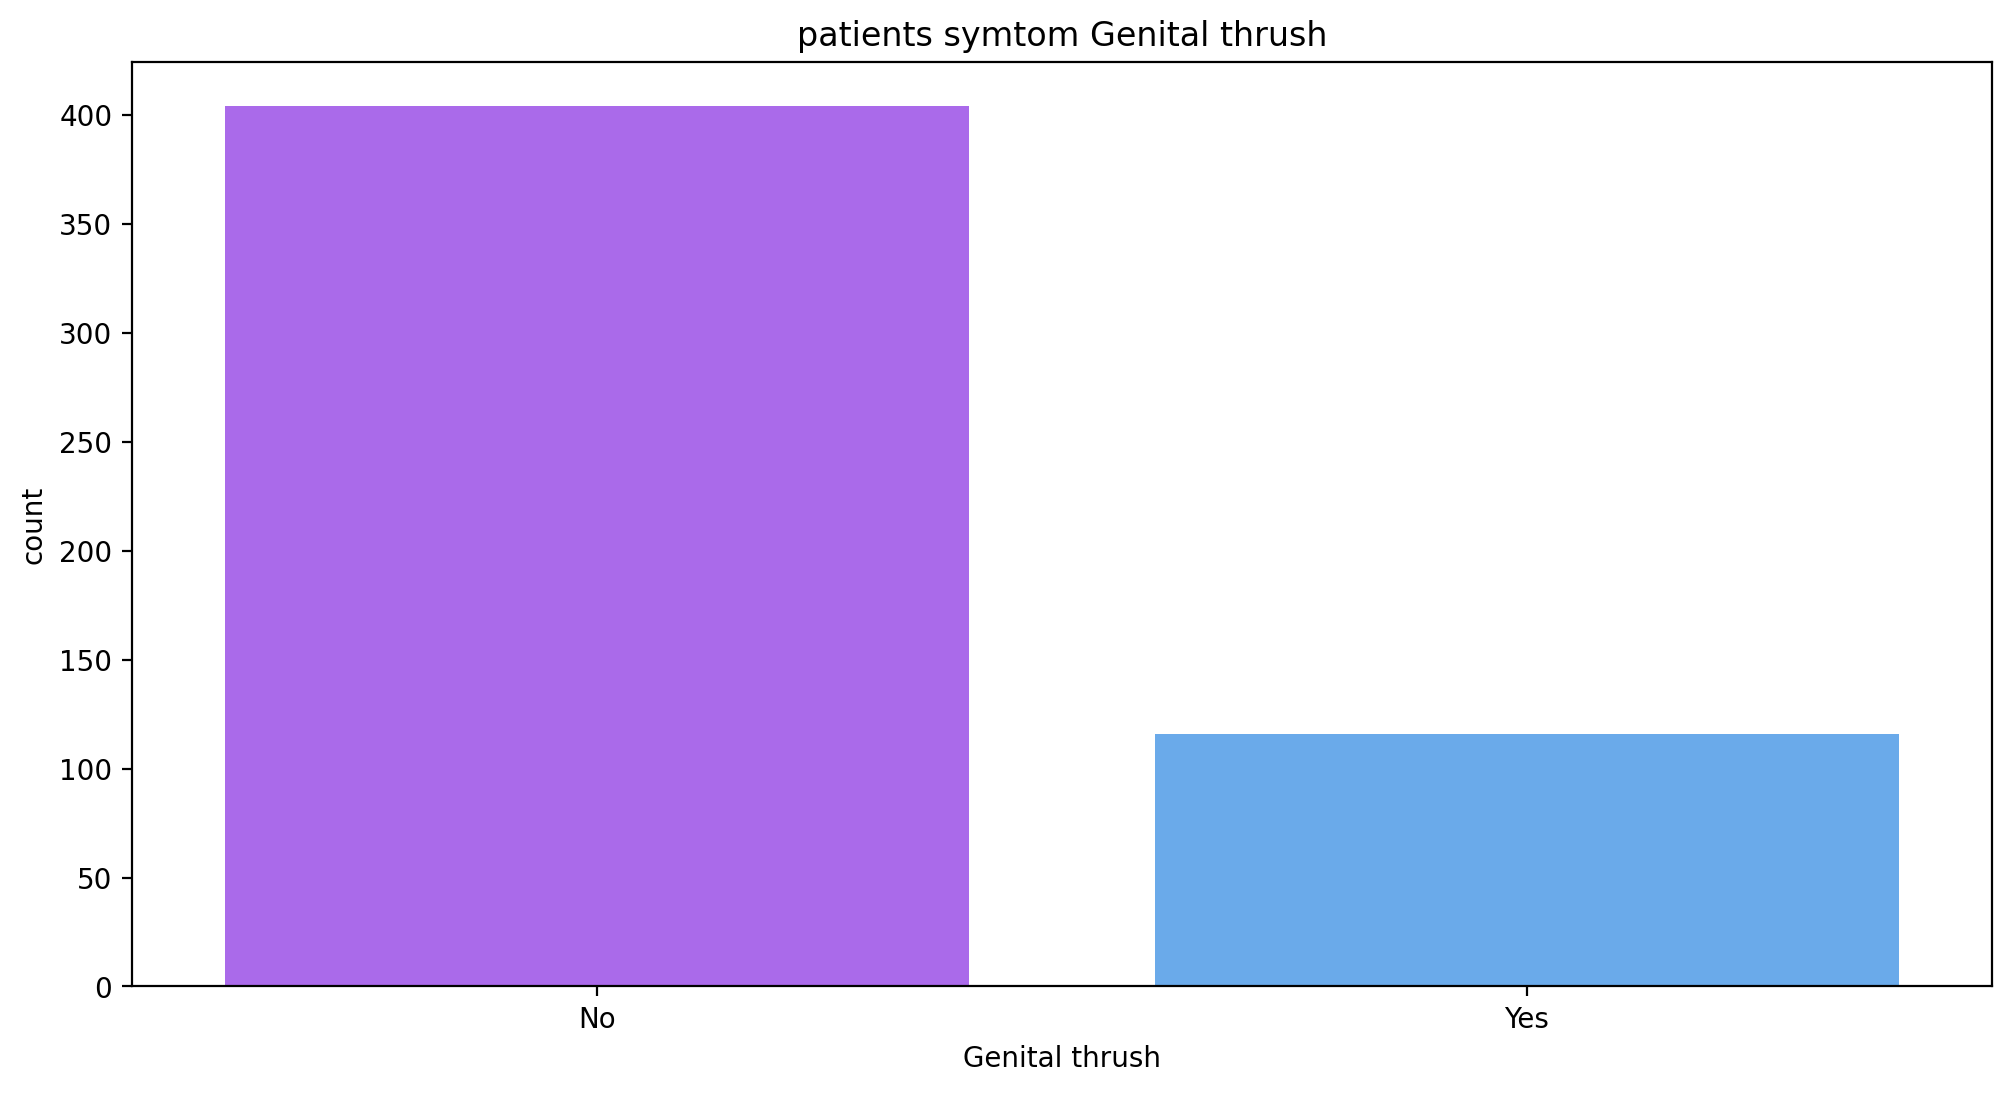

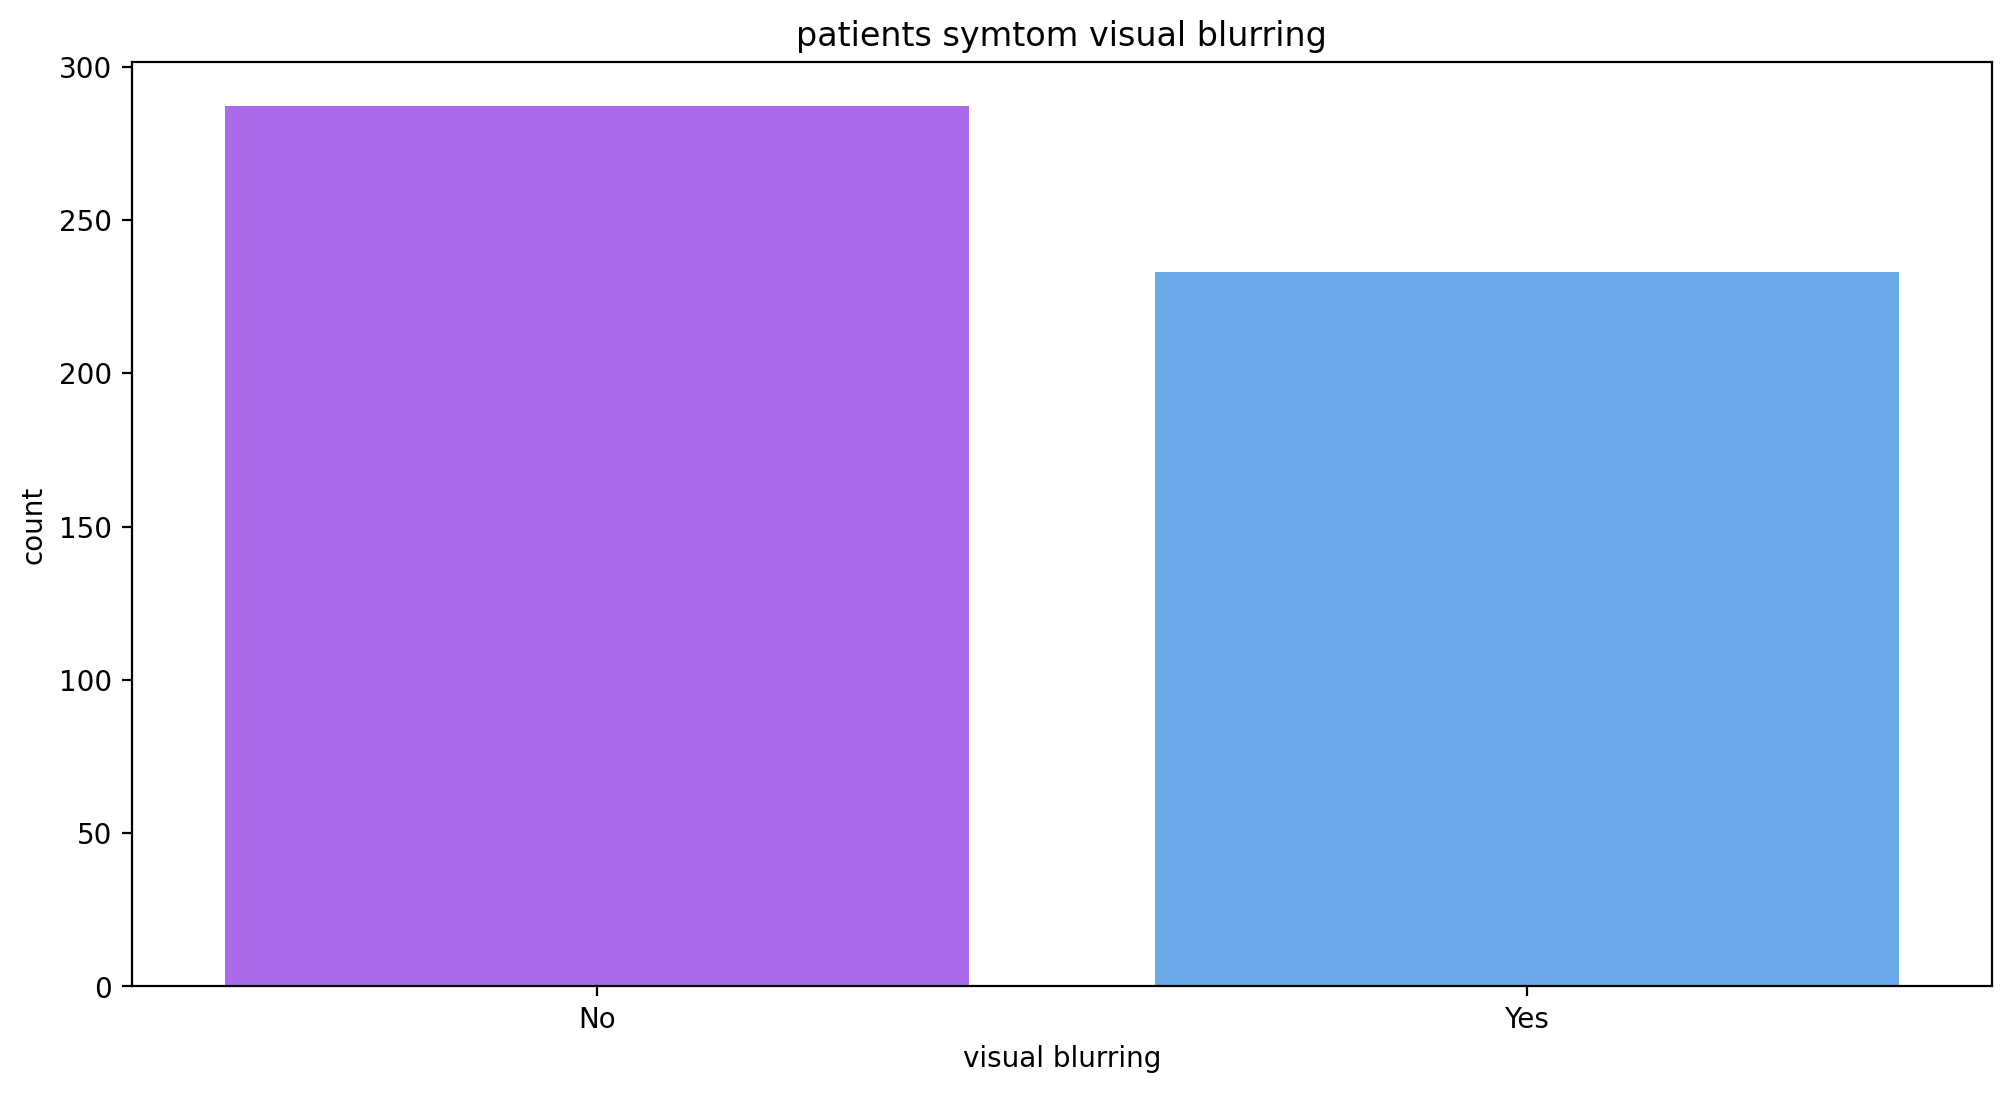

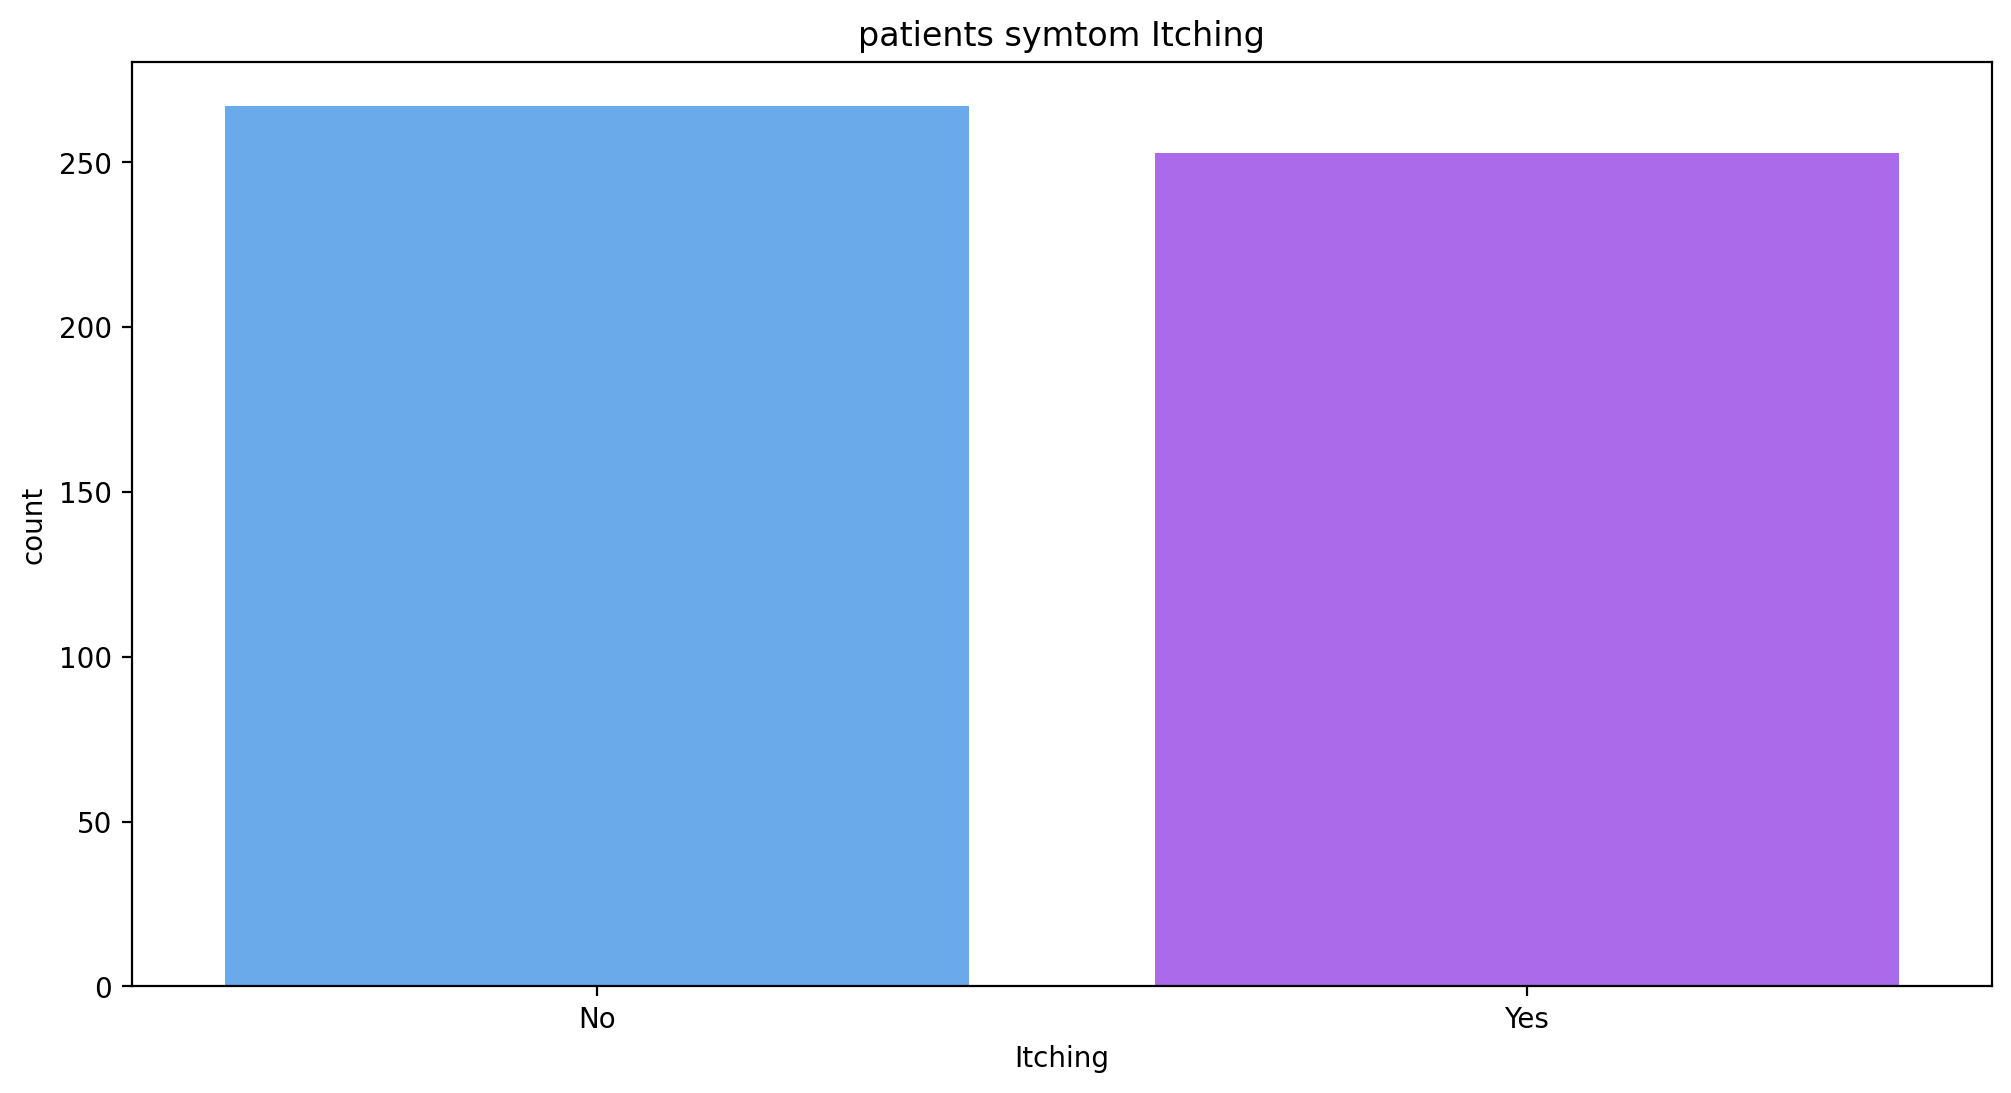

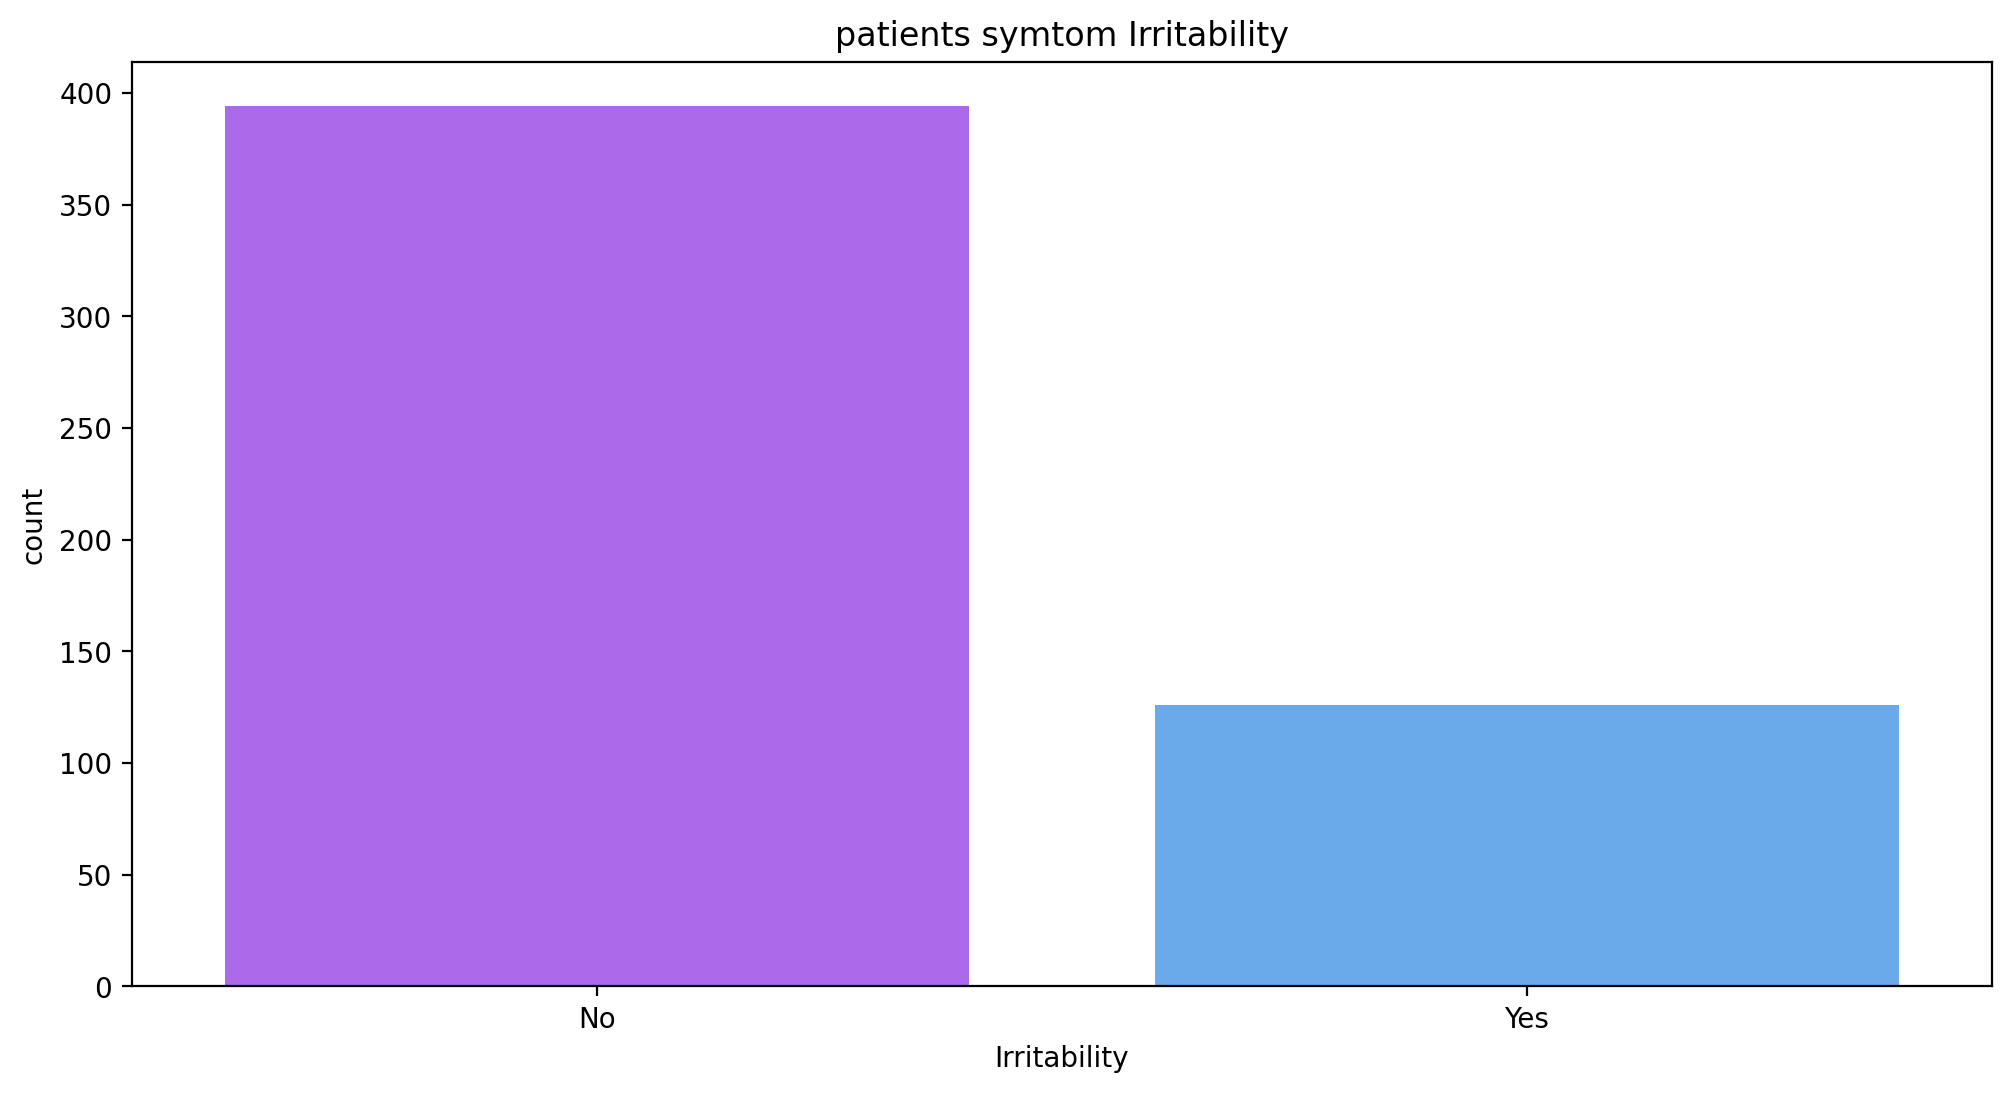

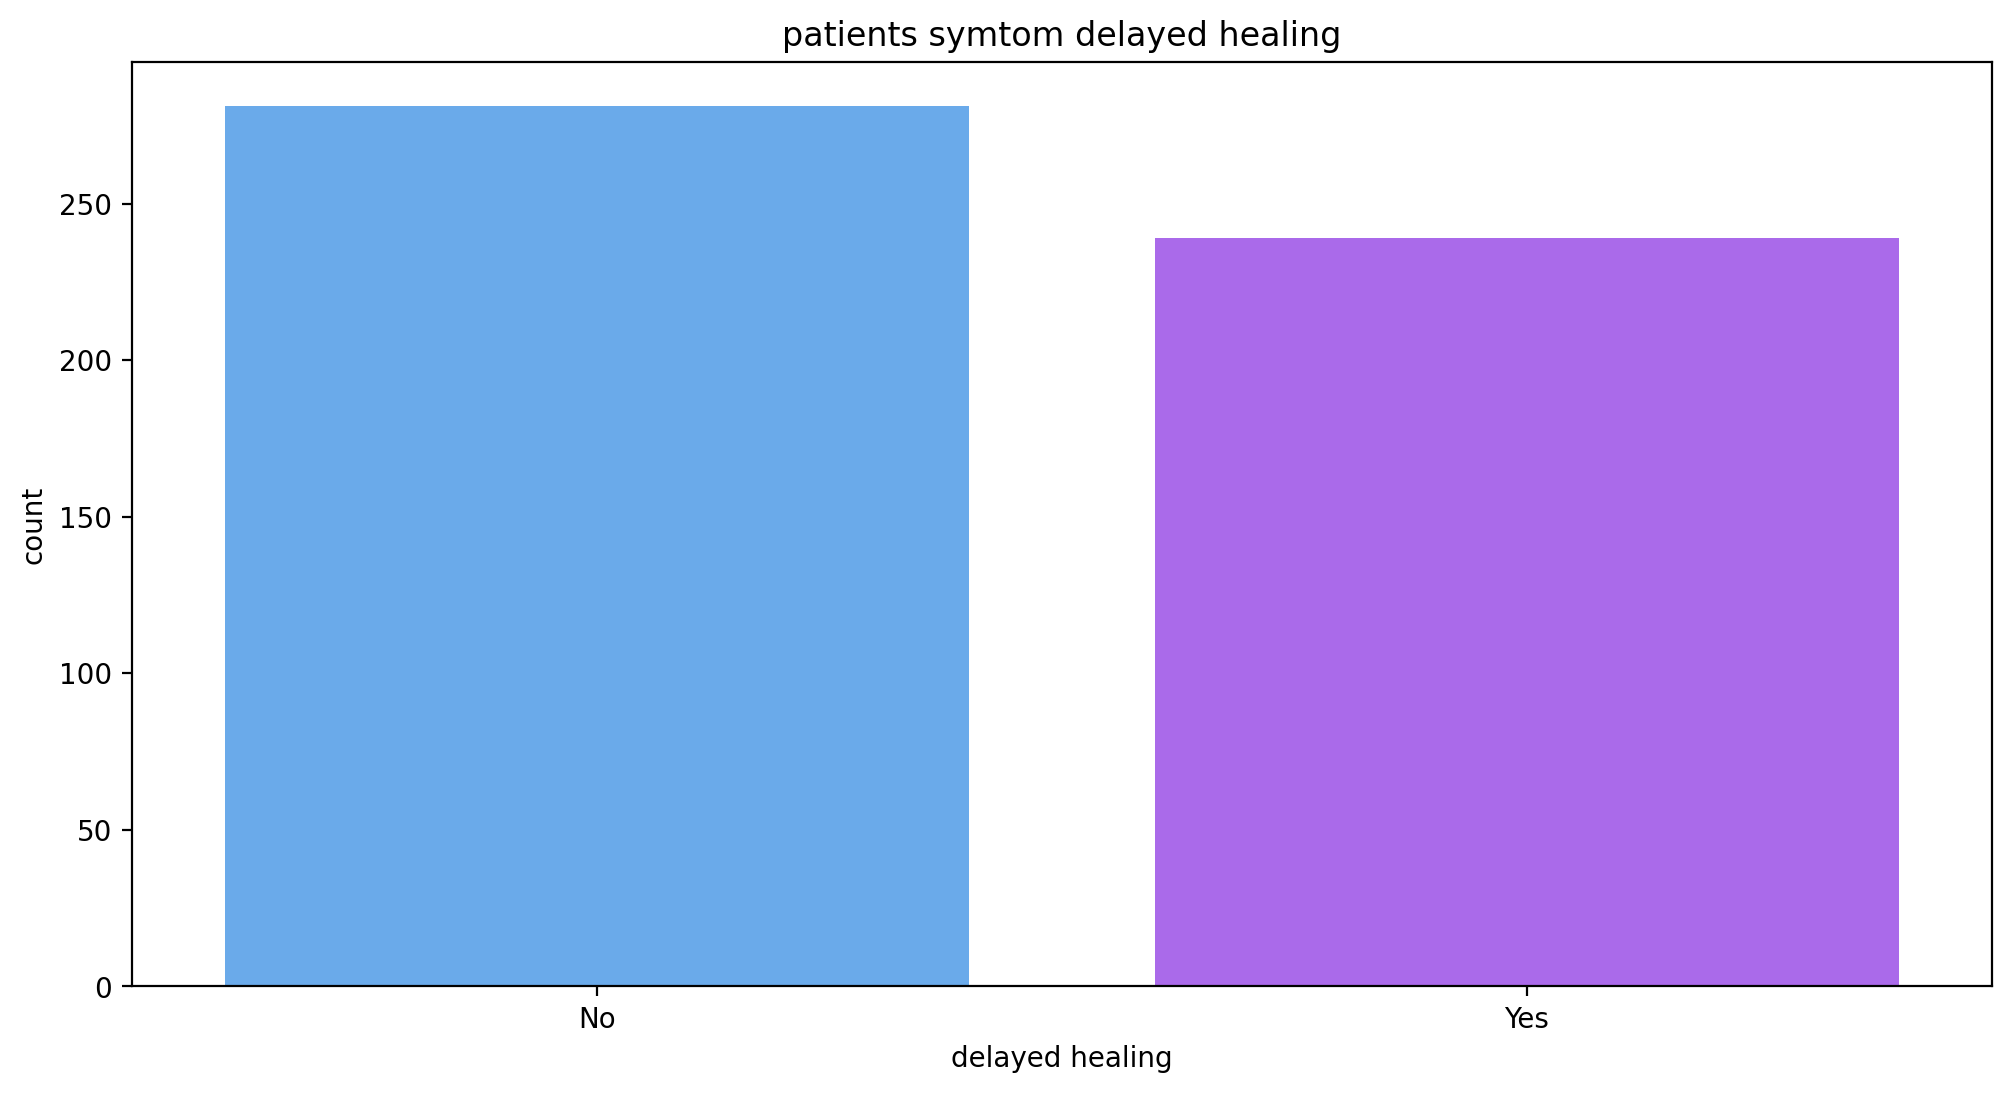

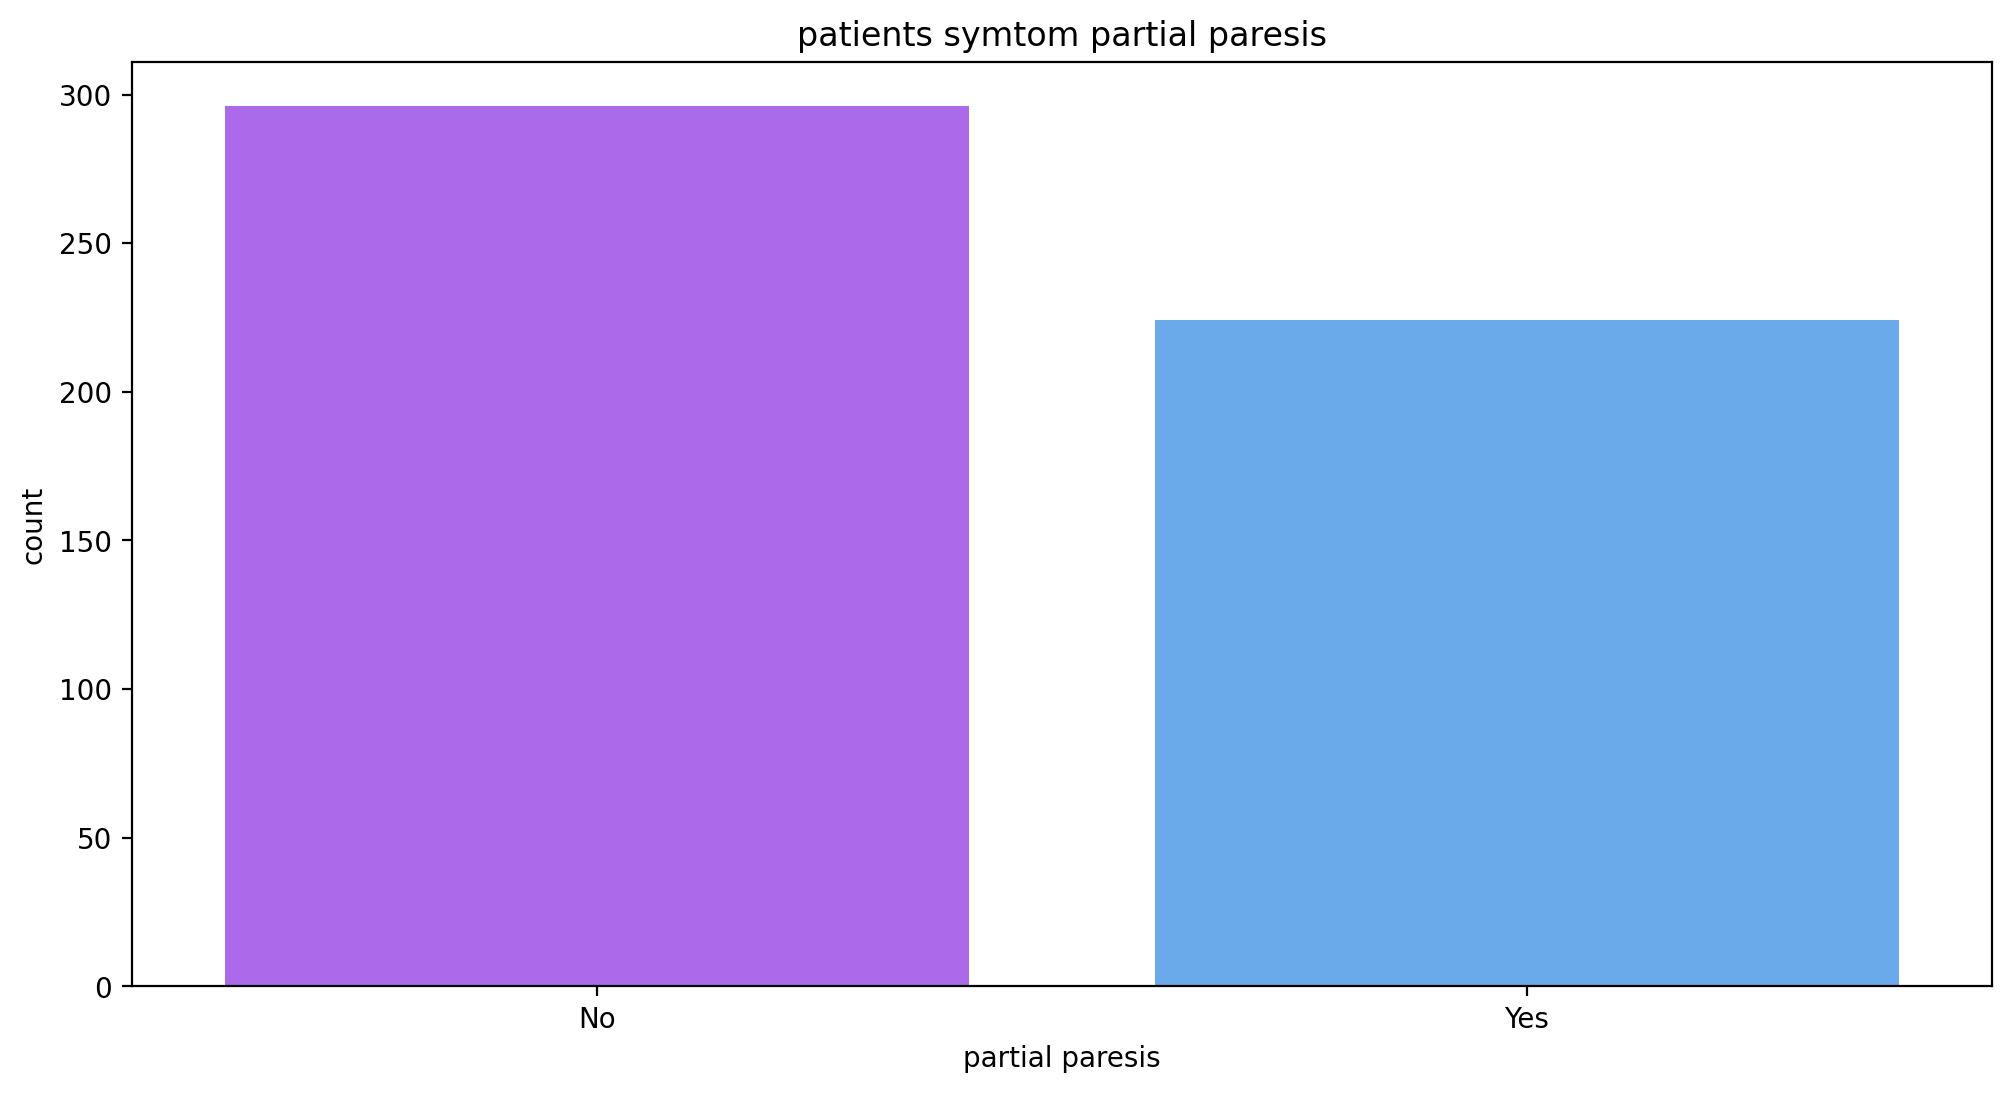

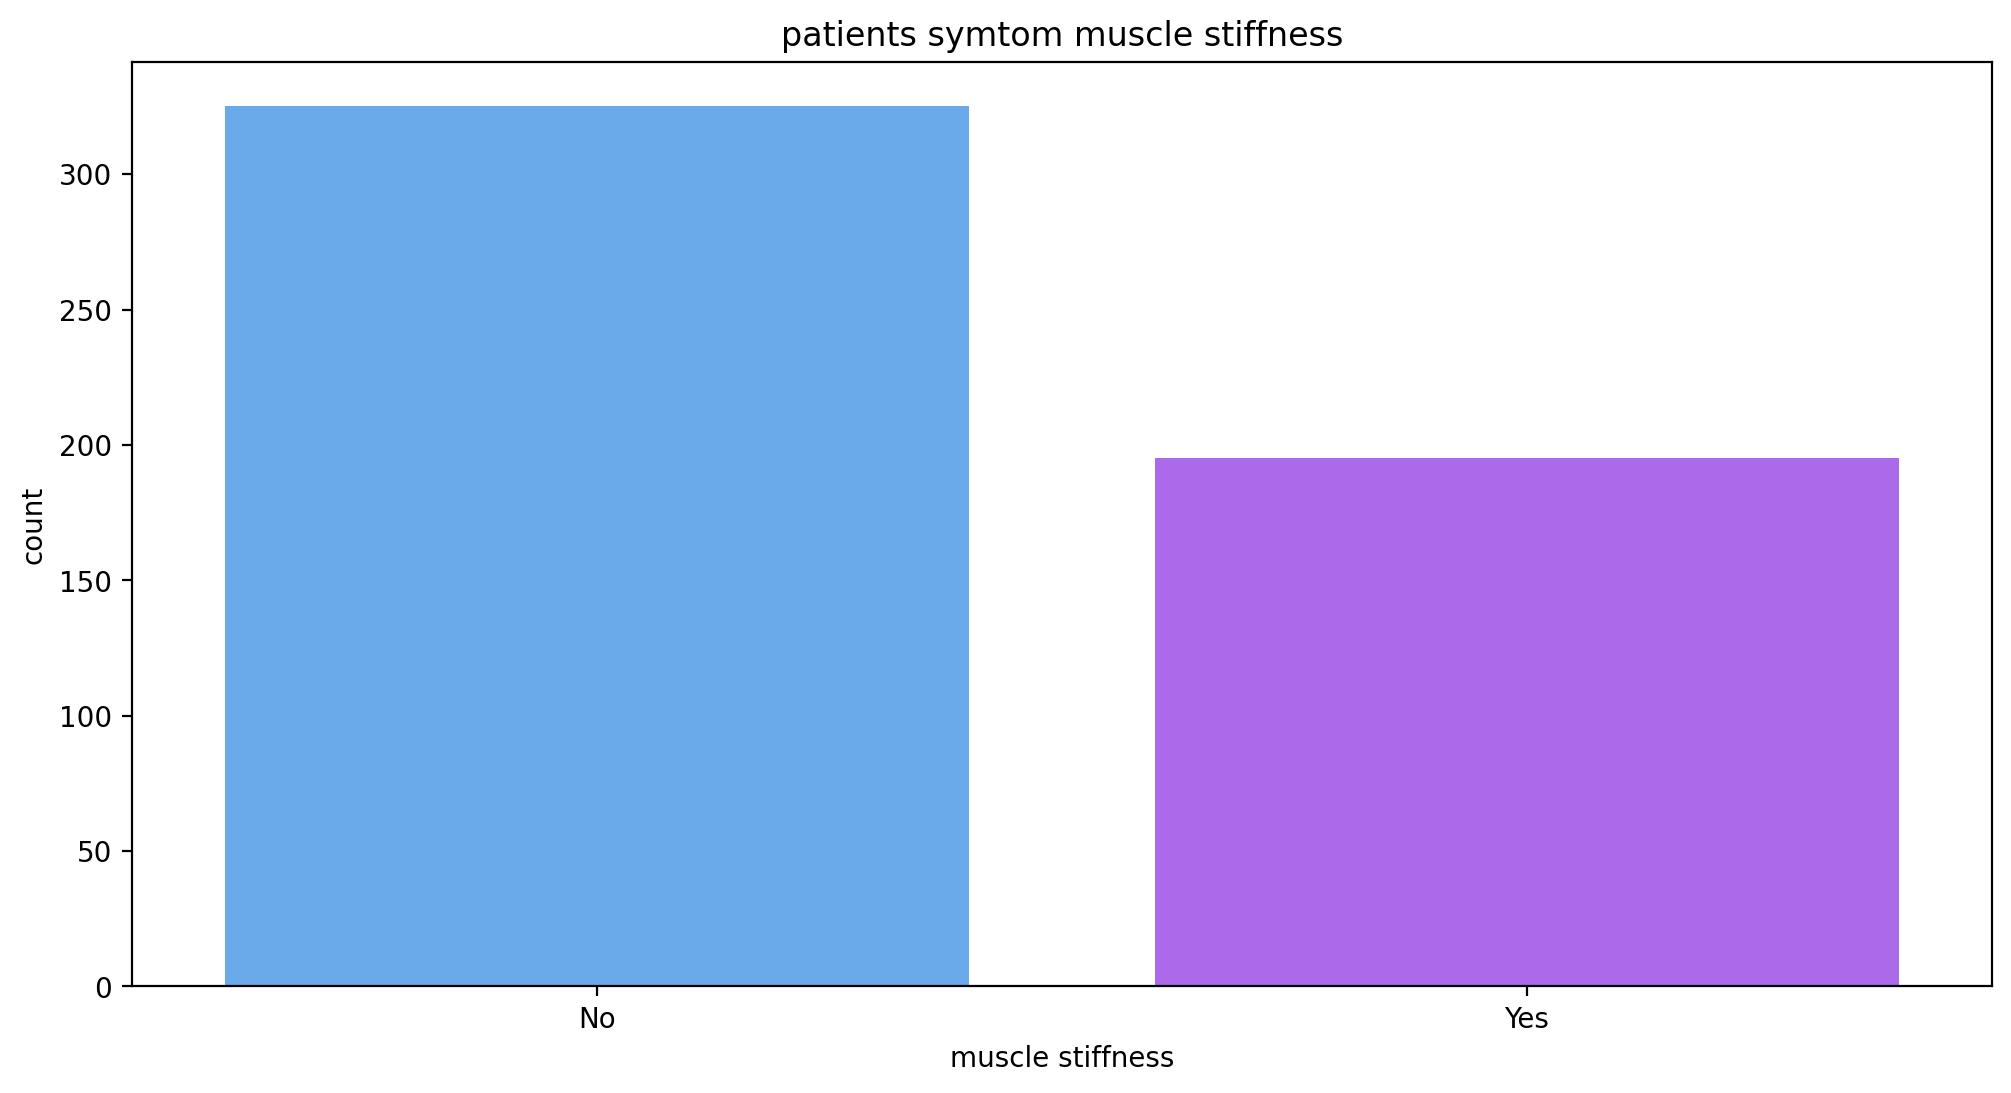

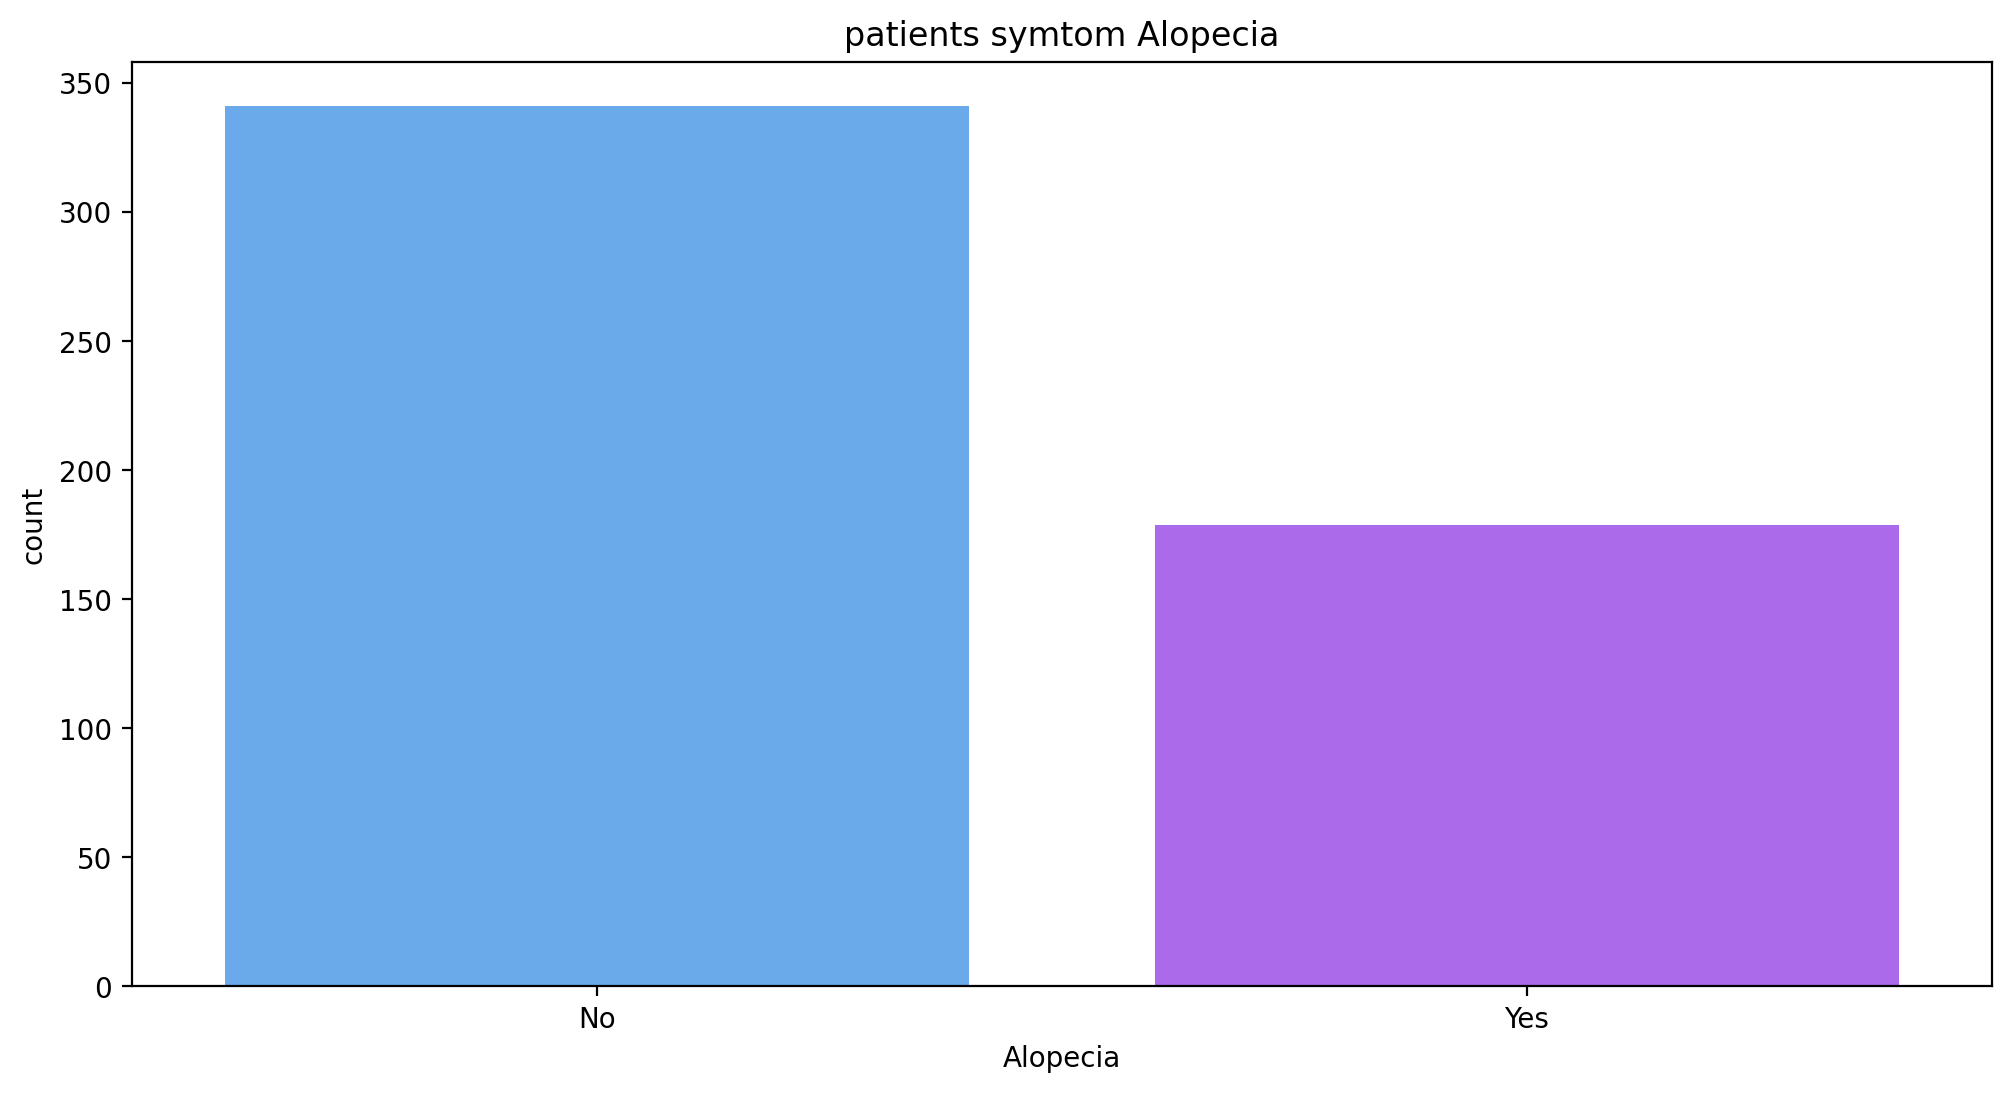

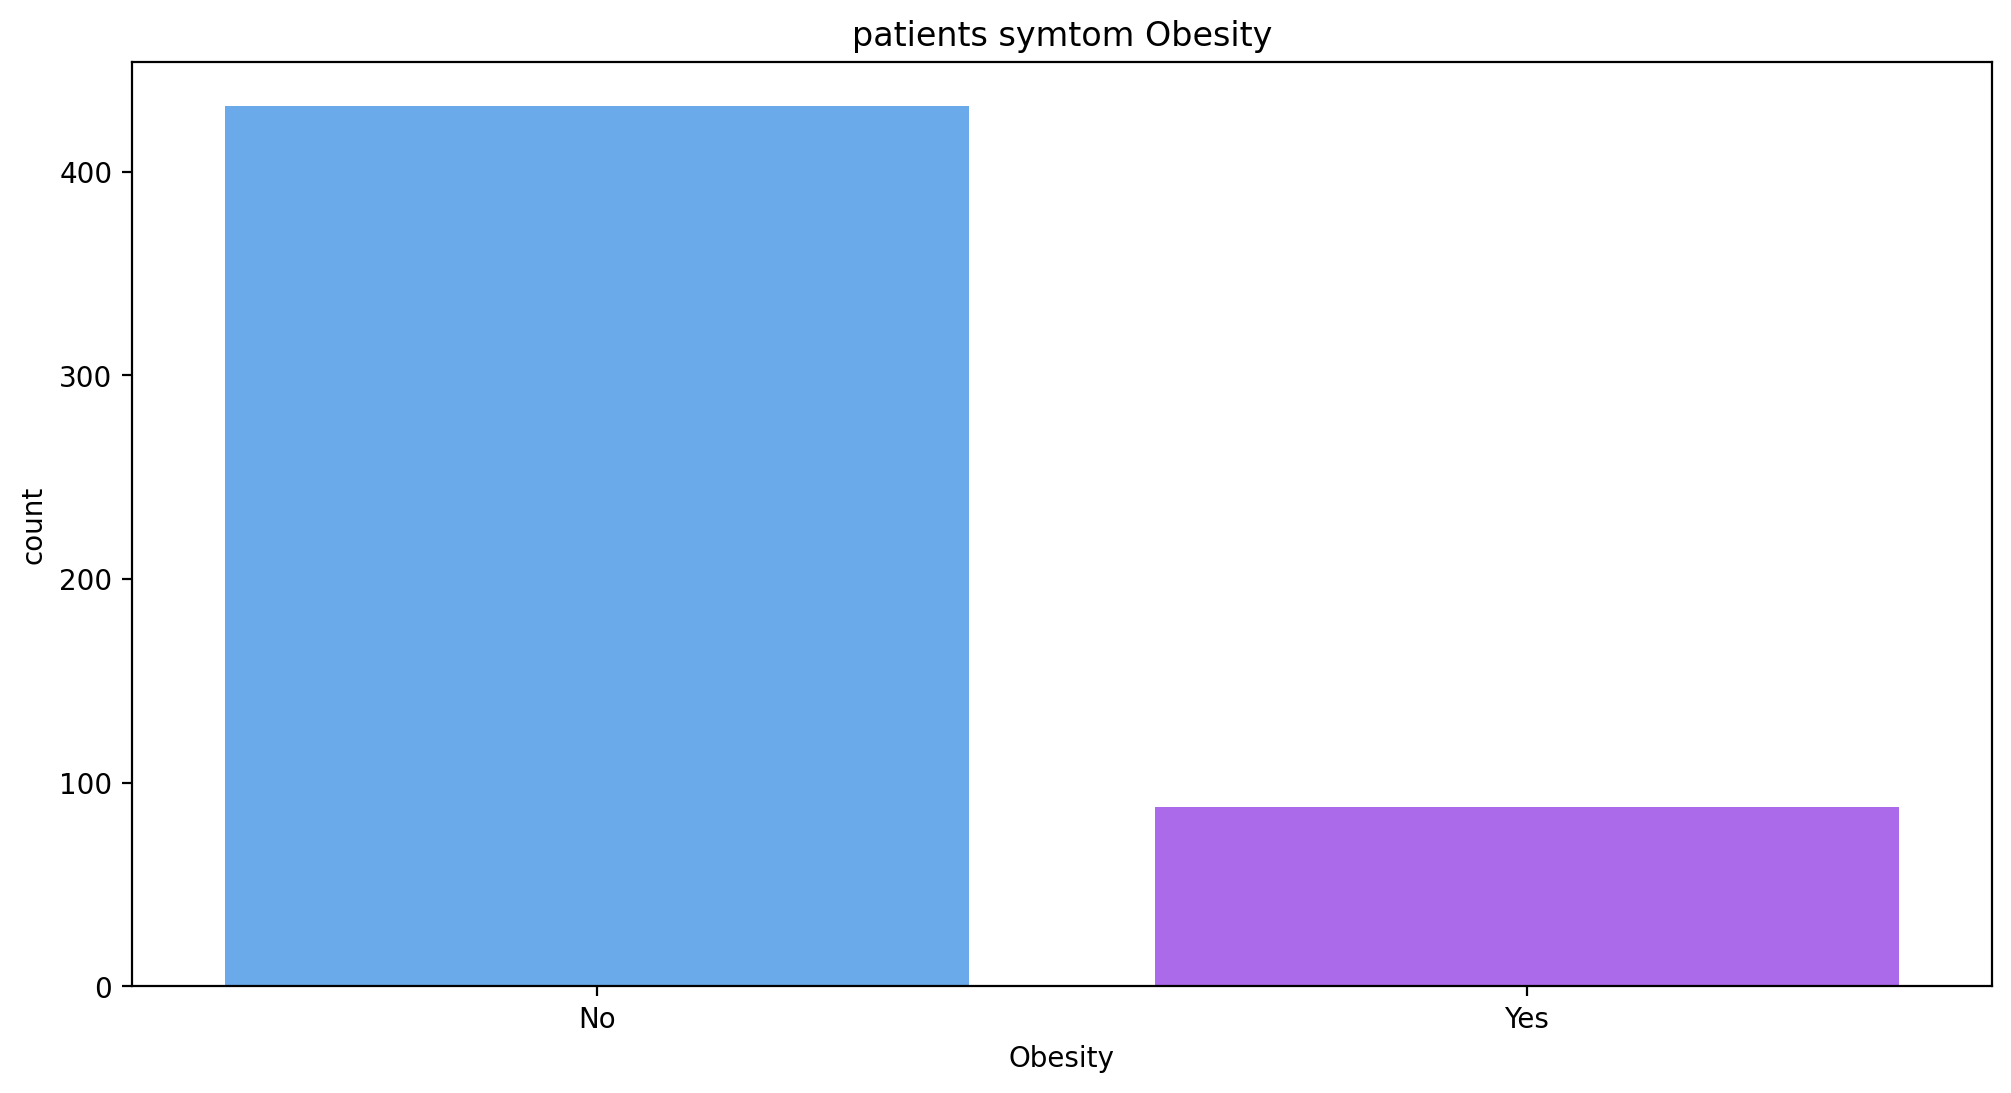

In [19]:
def cataplot(x):
      for i in x:
        order = data[i].value_counts().sort_values(ascending = False).index
        plt.figure(figsize = (12, 6), dpi = 200)
        sns.countplot(x = i, data = data, order = order, hue = i, palette = 'cool_r', legend=False)
        plt.title('patients symtom {}'.format(i))
        plt.show()
categorical_cols = [col for col in data.columns if col != 'Age' and col !='class']
cataplot(categorical_cols)

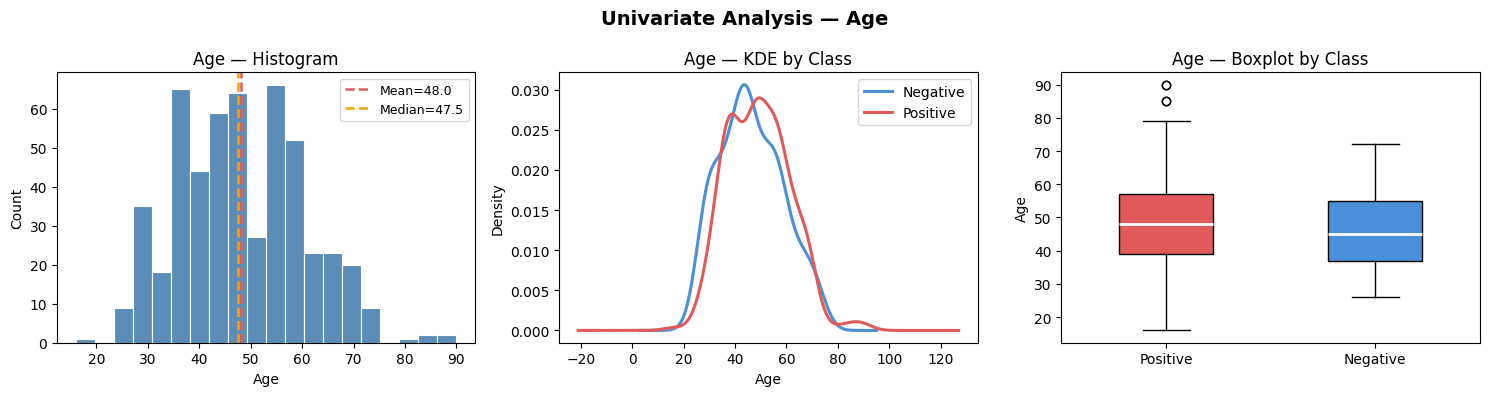

Age Stats:
          count   mean    std   min   25%   50%   75%   max
class                                                      
Negative  200.0  46.36  12.08  26.0  37.0  45.0  55.0  72.0
Positive  320.0  49.07  12.10  16.0  39.0  48.0  57.0  90.0


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(data['Age'], bins=20, color='#5B8DB8', edgecolor='white', linewidth=0.8)
axes[0].axvline(data['Age'].mean(), color='#E05A5A', linestyle='--', linewidth=1.8, label=f"Mean={df['Age'].mean():.1f}")
axes[0].axvline(data['Age'].median(), color='#F0A500', linestyle='--', linewidth=1.8, label=f"Median={df['Age'].median():.1f}")
axes[0].set_title('Age — Histogram')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

PALETTE = {'Positive': '#E05A5A', 'Negative': '#4A90D9'}
POS_C, NEG_C = '#E05A5A', '#4A90D9'


# KDE by class
for cls, grp in data.groupby('class'):
    grp['Age'].plot.kde(ax=axes[1], label=cls, color=PALETTE[cls], linewidth=2.2)
axes[1].set_title('Age — KDE by Class')
axes[1].set_xlabel('Age'); axes[1].legend()

# Boxplot by class
bp_data = [data[data['class']=='Positive']['Age'], data[df['class']=='Negative']['Age']]
bp = axes[2].boxplot(bp_data, patch_artist=True, widths=0.45,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [POS_C, NEG_C]):
    patch.set_facecolor(color)
axes[2].set_xticklabels(['Positive', 'Negative'])
axes[2].set_title('Age — Boxplot by Class')
axes[2].set_ylabel('Age')

plt.suptitle('Univariate Analysis — Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_age_univariate.png', bbox_inches='tight')
plt.show()

print("Age Stats:")
print(data.groupby('class')['Age'].describe().round(2))


**insights**


Class distribution:

Positive: 320 (~61.5%)

Negative: 200 (~38.5%)


 Mild class imbalance, but not severe
Metrics like F1 / ROC-AUC still valid without aggressive balancing
